### Testing code functionality
Amy - Sep 2026

***Maria's note***:
**Changes from Amy's notebook (dataset setup):**
- 20 x 20 D–T2 points instead of 10 x 10.
- 8 b-values (0-4) s 8 TEs (20–180 ms) instead of 20 b-values (0–10) s 20 TEs (10–200 ms), so far fewer measurements per voxel
- More voxels, 80 instead of 12.
- SVD rank R = 10 instead of 8
- New true compartments, the same as in demo_pipeline: centres at (D, T2) = (0.4, 90), (0.9, 55), (1.6, 120), with a different width for each
- Added a mean version of the NNLS initialisation (define_initial_C_NNLS_mean in optimiser), which averages the signals before solving NNLS
- Sections 3 and 4 use their own fixed random seed, so they run on the same data and can be compared


#### First create some GT spectra

In [38]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [39]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

b values  [ 0.   1.   2.5  5.   7.5 11.1 18.1 25. ] 

TE values [28.12  33.    38.017 45.    60.    78.   ] 



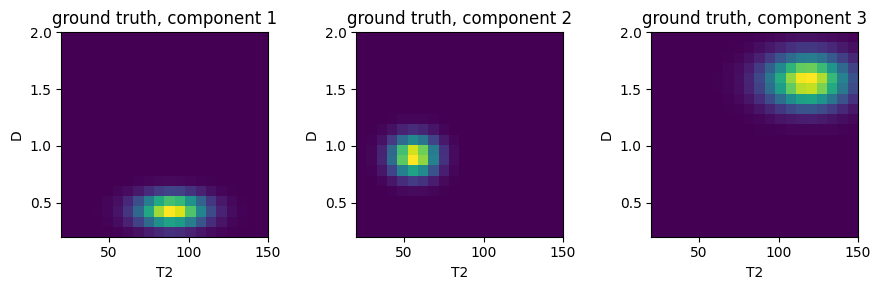

In [40]:

Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20

voxels_to_show = [10, 20, 30, 40, 50, 60, 70]

# three ground-truth compartments, each a Gaussian blob in (D, T2) space
D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

# acquisition of the real macaque data
b_vals = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0]) / 1000.0   # s/mm² -> ms/µm² (same units as D)
TE_vals = np.array([28.12, 33.0, 38.017, 45.0, 60.0, 78.0])   # ms
print("b values ", b_vals, "\n")
print("TE values", TE_vals, "\n")

# Define fitting parameters
K=3; # Number of canonical spectra
V=80; # Number of voxels
R=10   # Rank for SVD    

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 
# Create A matrix from b_vals x TE_vals, b-major (b outer, TE inner) like create_A_matrix,
# so initialize_M0_monoexponential(Y, b_vals, TE_vals) expands the rows in the same order
B_mesh, TE_mesh = np.meshgrid(b_vals, TE_vals, indexing="ij")
A = create_A_matrix_from_acquisition(D, T2, B_mesh.ravel(), TE_mesh.ravel())
# Create true C - canonical spectra
# Here have hardcoded centres
C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


#### Run optimisation

I added a function, define_initial_C_NNLS_mean, that averages the signals over all voxels first and then solves one NNLS on the average. The original define_initial_C_NNLS solves NNLS on each voxel and averages the spectra. Both then use k-means on the averaged spectrum to find the component centres and place one Gaussian at each centre.

**Result:** The original (spectrum-averaged) version puts the components in the wrong places here. The new signal-averaged version finds all three in the right places. Only the second is kept, so everything below starts from the signal-averaged initialisation.


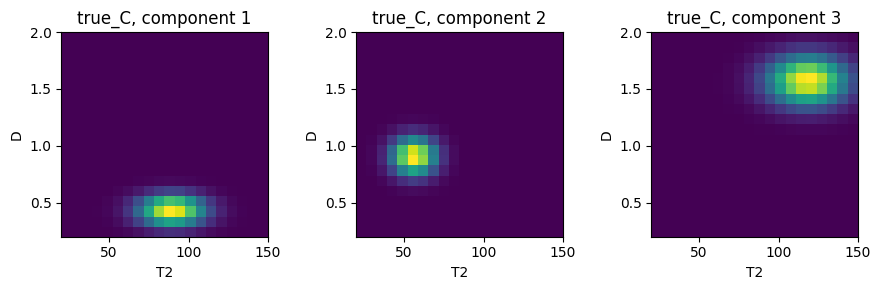

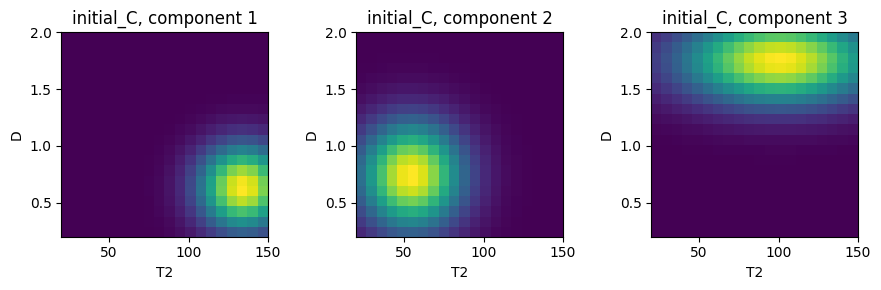

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [319.00370509 297.09710203 289.94371287 314.12414949 312.40140933
 282.6821295  301.61252737 280.98569879 291.72444821 289.67084012
 306.24788843 296.00095668 295.5674187  276.1450498  296.2700646
 283.28330717 307.1387354  318.58496099 272.67058893 294.11346155
 297.43894867 301.67093811 294.55423399 284.3953325  290.37678823
 287.98411956 279.85545247 282.7787262  282.65995226 294.4058513
 297.36879822 292.74268272 280.32187484 302.00724429 290.39105615
 298.24857689 282.35548802 308.78553196 276.22362369 267.19766371
 302.7530943  295.57988637 312.13730728 302.82

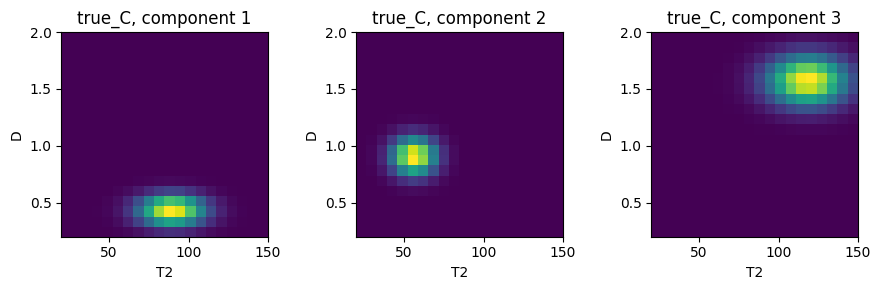

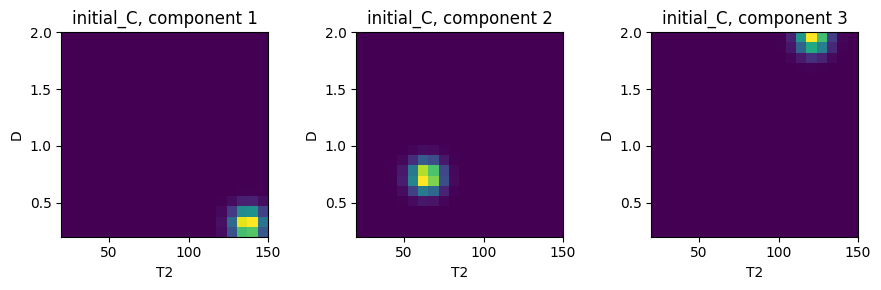

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [319.00370509 297.09710203 289.94371287 314.12414949 312.40140933
 282.6821295  301.61252737 280.98569879 291.72444821 289.67084012
 306.24788843 296.00095668 295.5674187  276.1450498  296.2700646
 283.28330717 307.1387354  318.58496099 272.67058893 294.11346155
 297.43894867 301.67093811 294.55423399 284.3953325  290.37678823
 287.98411956 279.85545247 282.7787262  282.65995226 294.4058513
 297.36879822 292.74268272 280.32187484 302.00724429 290.39105615
 298.24857689 282.35548802 308.78553196 276.22362369 267.19766371
 302.7530943  295.57988637 312.13730728 302.82

In [41]:
# Set intial conditions
C0=define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)

# Set intial conditions
C0=define_initial_C_NNLS_mean(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)





iter 0: loss=1810.3255, fit_err=134328.858917, sigma2=36.000000
iter 100: loss=1778.0878, fit_err=132012.561435, sigma2=36.000000
iter 200: loss=1778.0877, fit_err=132012.549945, sigma2=36.000000


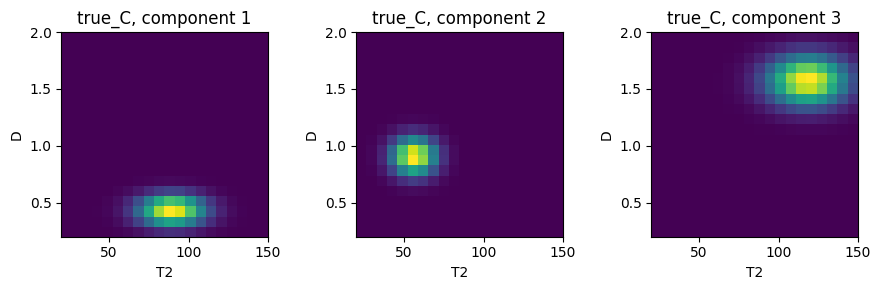

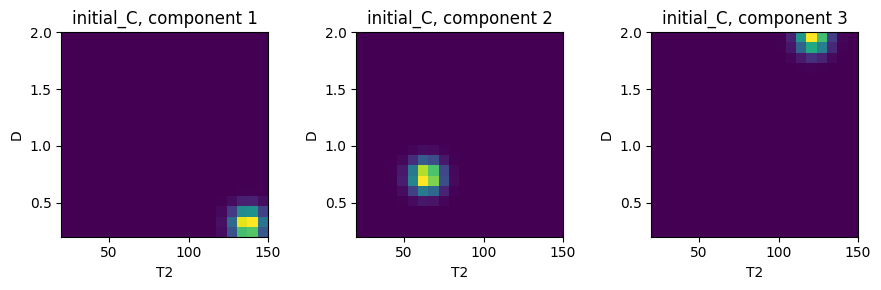

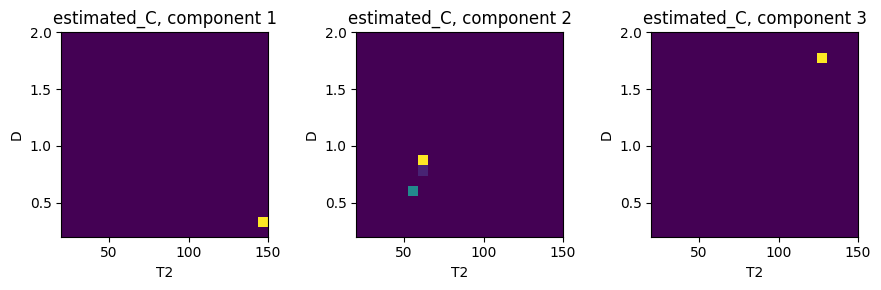

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [319.00445421 297.09928384 289.94577295 314.11112218 312.40394171
 282.68740193 301.61475824 280.98981527 291.72666436 289.67146423
 306.24970658 296.00161878 295.57086967 276.14829117 296.26908491
 283.28651785 307.13829695 318.58411298 272.67469851 294.11425607
 297.44012885 301.67022255 294.55640426 284.39700027 290.37990747
 287.98869307 279.85741276 282.78127461 282.66201179 294.40912551
 297.36790013 292.74805182 280.32607248 302.007356   290.3959127
 298.25042023 282.35789901 308.78526147 276.22849819 267.20267067
 302.75304107 295.58211217 312.12999698 302

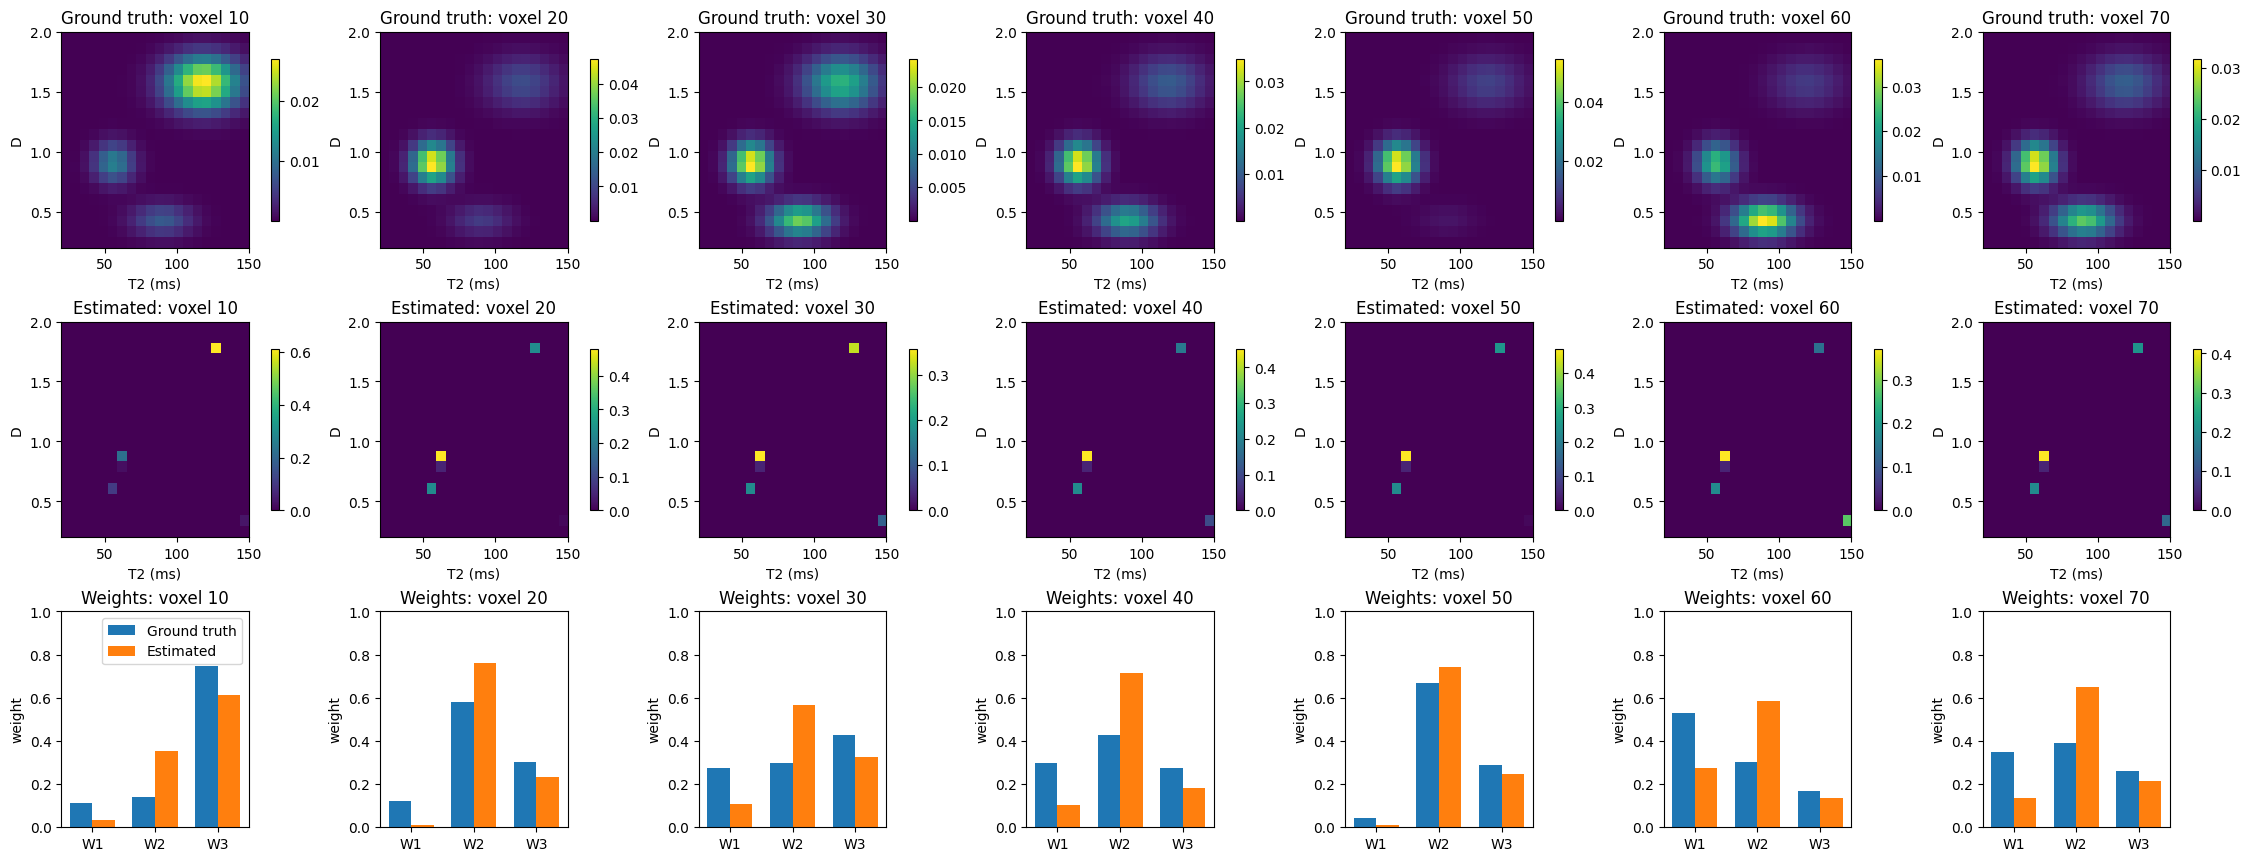

In [42]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # IDEALLY WE WANT TO NOT HAVE THIS, OR HAVE THE MODEL FAIRLY INSENSITIVE TO THE NOISE LEVEL BEING A LITTLE WRONG
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=0.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=100,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


Maria's note: Starting from the signal-averaged initialisation, the weights are recovered well. The spectra shrink to single spikes at roughly the right positions, so the peak locations are right but the shape and width are lost




Note this constrained optimisation of C (not C_small) has several constraint options:

- c_smoothness
Makes each canonical D–T2 spectrum spatially smooth across neighbouring grid cells.

- c_sparsity
Encourages each canonical spectrum to concentrate its mass into fewer grid locations.

- c_diversity
Discourages different canonical spectra from overlapping at the same D–T2 locations.

Other constraints already in the model (not on C):

- C simplex constraint
Each canonical spectrum is non-negative and sums to one.

- W simplex constraint
Each voxel’s component weights are non-negative and sum to one.

- M0 > 0
Voxel signal scale cannot be negative.

- lam
Ridge/Gaussian penalty on reduced C_small; shrinks its overall magnitude. Not physical D–T2 smoothness.

- Dirichlet alpha on W
A probabilistic prior favouring globally more pure (alpha < 1) or more even (alpha > 1) voxel weights.

- weight_entropy
Non-Dirichlet alternative that encourages individual voxel weights to be sparse/dominant.

#### We can make C smoother with the smoothness option

iter 0: loss=1811.8576, fit_err=134342.444102, sigma2=36.000000
iter 1: loss=1793.9865, fit_err=133021.089304, sigma2=36.000000
iter 2: loss=1786.7622, fit_err=132493.254802, sigma2=36.000000
iter 3: loss=1782.8031, fit_err=132208.791791, sigma2=36.000000
iter 4: loss=1780.4333, fit_err=132036.230270, sigma2=36.000000
iter 5: loss=1778.9905, fit_err=131933.514778, sigma2=36.000000
iter 6: loss=1778.1289, fit_err=131870.624039, sigma2=36.000000
iter 7: loss=1777.6036, fit_err=131830.900927, sigma2=36.000000
iter 8: loss=1777.2793, fit_err=131805.110124, sigma2=36.000000
iter 9: loss=1777.0734, fit_err=131787.945619, sigma2=36.000000
iter 10: loss=1776.9408, fit_err=131775.947273, sigma2=36.000000
iter 11: loss=1776.8534, fit_err=131767.615425, sigma2=36.000000
iter 12: loss=1776.7934, fit_err=131761.369128, sigma2=36.000000
iter 13: loss=1776.7513, fit_err=131756.519978, sigma2=36.000000
iter 14: loss=1776.7203, fit_err=131752.760833, sigma2=36.000000
iter 15: loss=1776.6968, fit_err=13

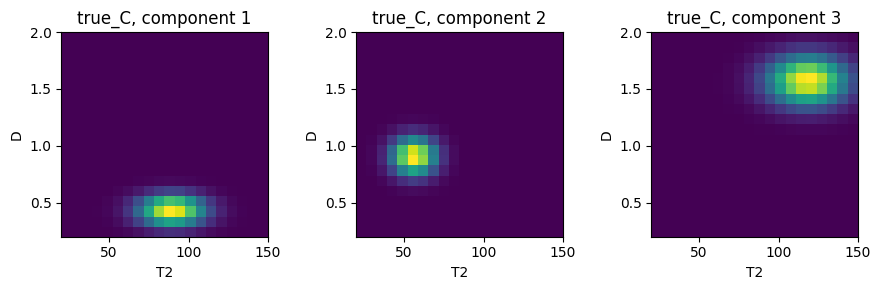

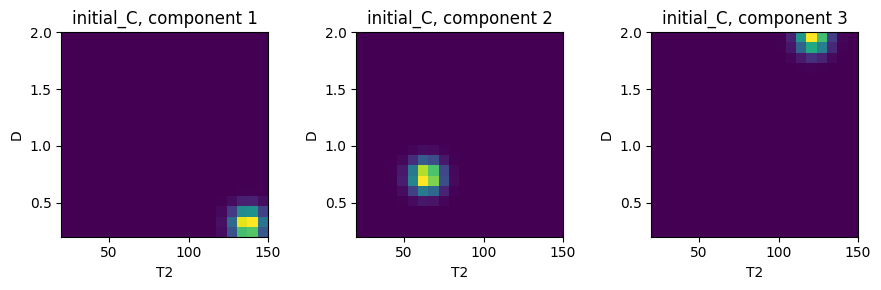

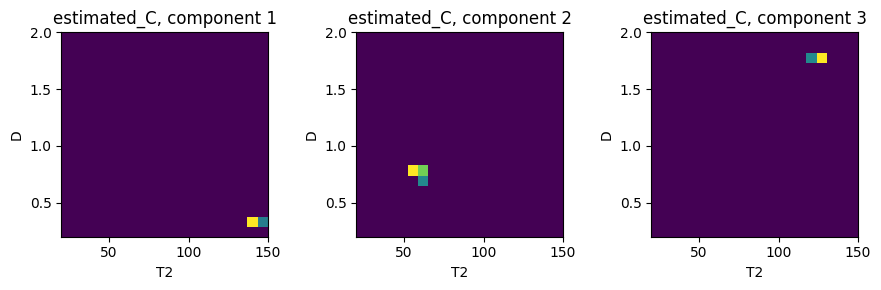

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [319.00448373 297.09931688 289.94576058 314.11184554 312.40396427
 282.68742792 301.61481224 280.98983956 291.72664701 289.6714895
 306.24976551 296.00167045 295.57093354 276.14842662 296.26912478
 283.28666246 307.13831138 318.58406261 272.6748132  294.11426753
 297.4408605  301.67023566 294.55645217 284.39706274 290.38000321
 287.98877082 279.85739677 282.78132743 282.6620609  294.40920081
 297.36789611 292.74815974 280.32618576 302.00737416 290.39599023
 298.25047832 282.35800777 308.78529849 276.22844676 267.20283922
 302.75304761 295.58216037 312.13074848 302

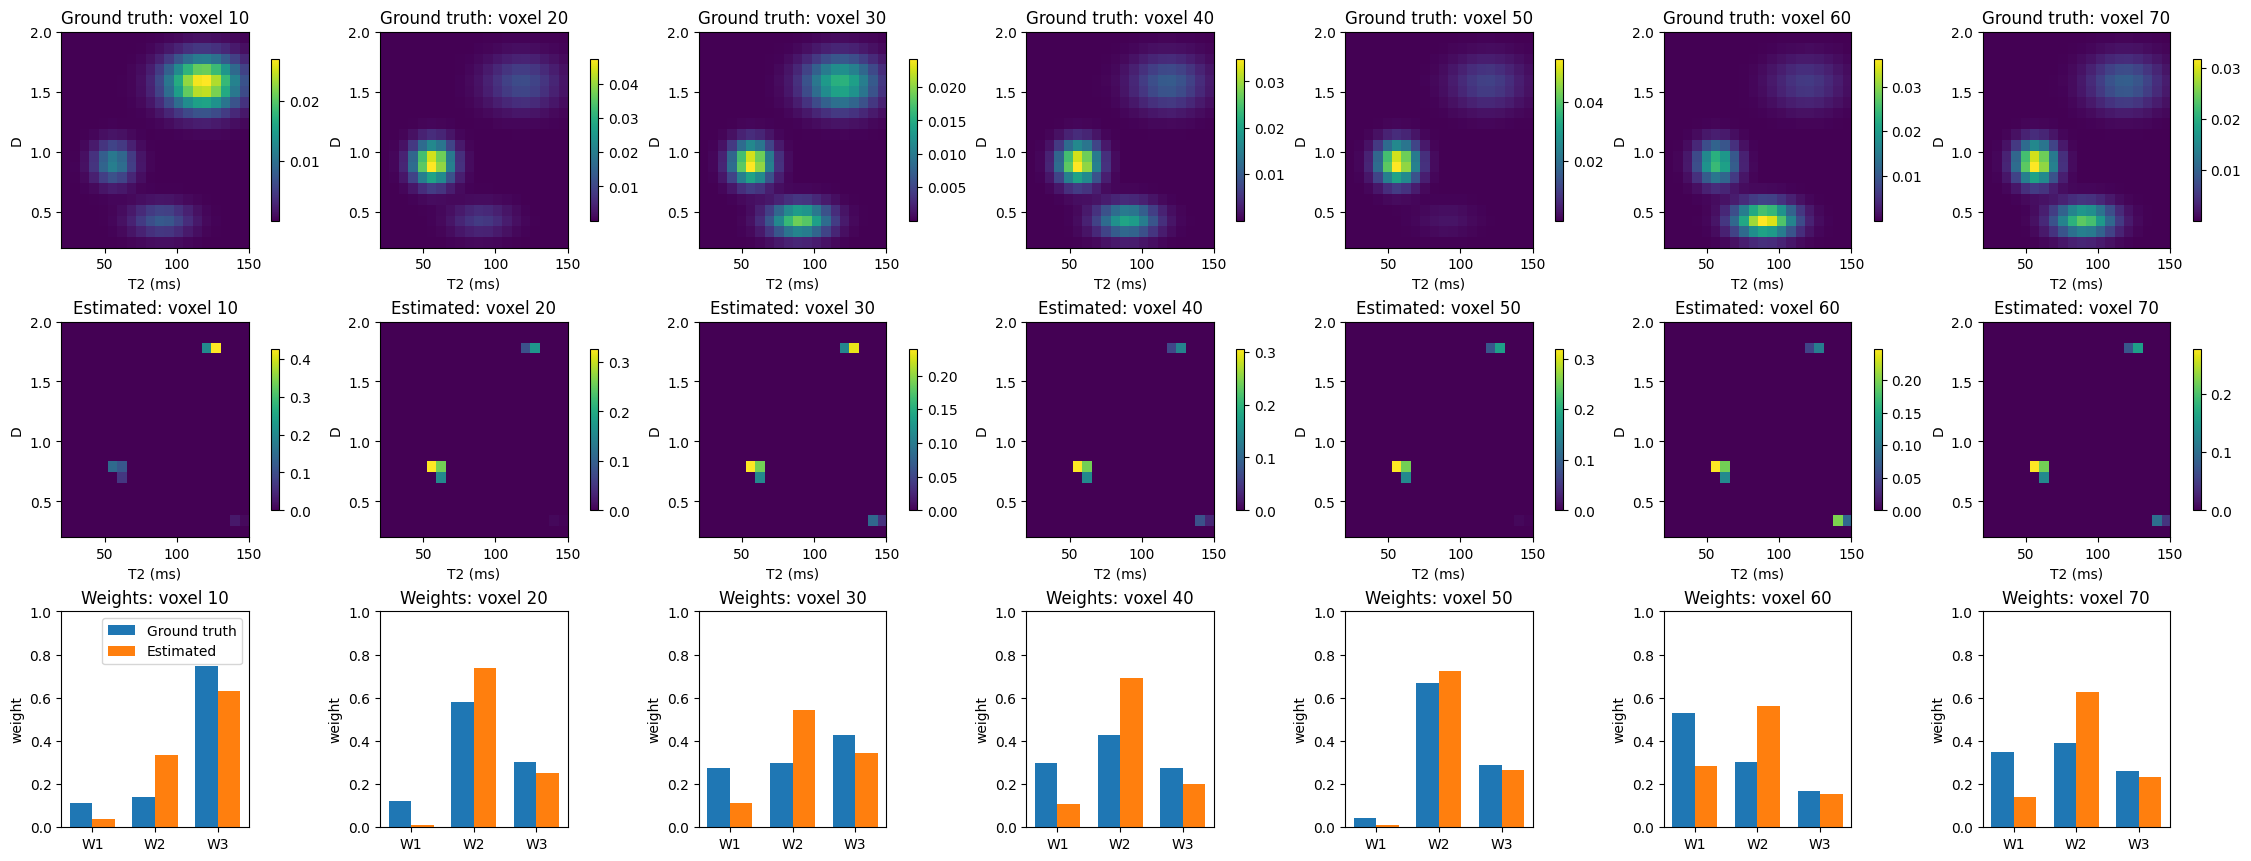

In [43]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here
        
        c_sparsity=0.0,            # make C sparse
        c_smoothness=1.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


**Result:** At this strength smoothness has little visible effect. The spectra are still spiky and the weights are unchanged. A stronger value is needed to see an effect, most likely


#### or sparse

iter 0: loss=1816.7789, fit_err=134731.608659, sigma2=36.000000
iter 1: loss=1798.0306, fit_err=133372.884776, sigma2=36.000000
iter 2: loss=1789.8937, fit_err=132786.977340, sigma2=36.000000
iter 3: loss=1785.2396, fit_err=132457.013087, sigma2=36.000000
iter 4: loss=1782.5326, fit_err=132270.724166, sigma2=36.000000
iter 5: loss=1780.8802, fit_err=132165.953705, sigma2=36.000000
iter 6: loss=1780.1027, fit_err=132112.793672, sigma2=36.000000
iter 7: loss=1780.0958, fit_err=132112.258052, sigma2=36.000000
iter 8: loss=1780.0953, fit_err=132112.172795, sigma2=36.000000
iter 9: loss=1780.0949, fit_err=132112.104341, sigma2=36.000000
iter 10: loss=1780.0947, fit_err=132112.049418, sigma2=36.000000
iter 11: loss=1780.0945, fit_err=132112.005429, sigma2=36.000000
iter 12: loss=1780.0943, fit_err=132111.969092, sigma2=36.000000
iter 13: loss=1780.0942, fit_err=132111.939786, sigma2=36.000000
iter 14: loss=1780.0941, fit_err=132111.915747, sigma2=36.000000
iter 15: loss=1780.0941, fit_err=13

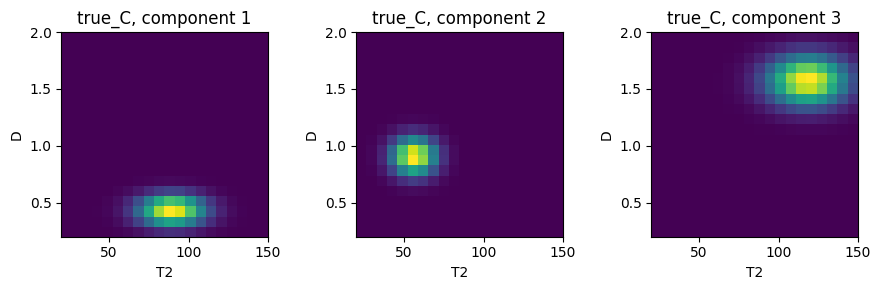

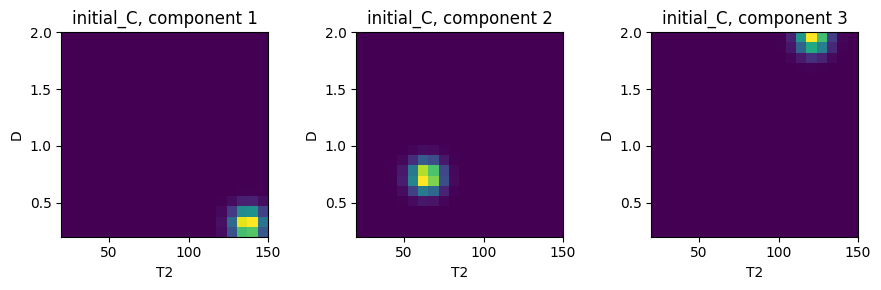

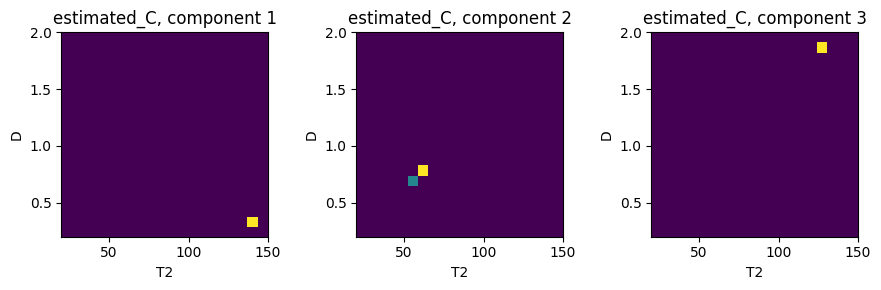

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [319.00437236 297.09935865 289.94566498 314.10964643 312.40403137
 282.6874383  301.61490029 280.98993424 291.72661023 289.67131787
 306.25015488 296.00201727 295.5711344  276.14906084 296.26937588
 283.28705279 307.13818974 318.58384753 272.67502516 294.11432597
 297.43917229 301.67024704 294.55666764 284.39747404 290.38021387
 287.98900808 279.8571652  282.78162694 282.66216338 294.40940812
 297.36779497 292.74855497 280.32626036 302.00726622 290.39641884
 298.25085884 282.35843709 308.78570165 276.22841417 267.20325253
 302.75277111 295.58241697 312.12925059 30

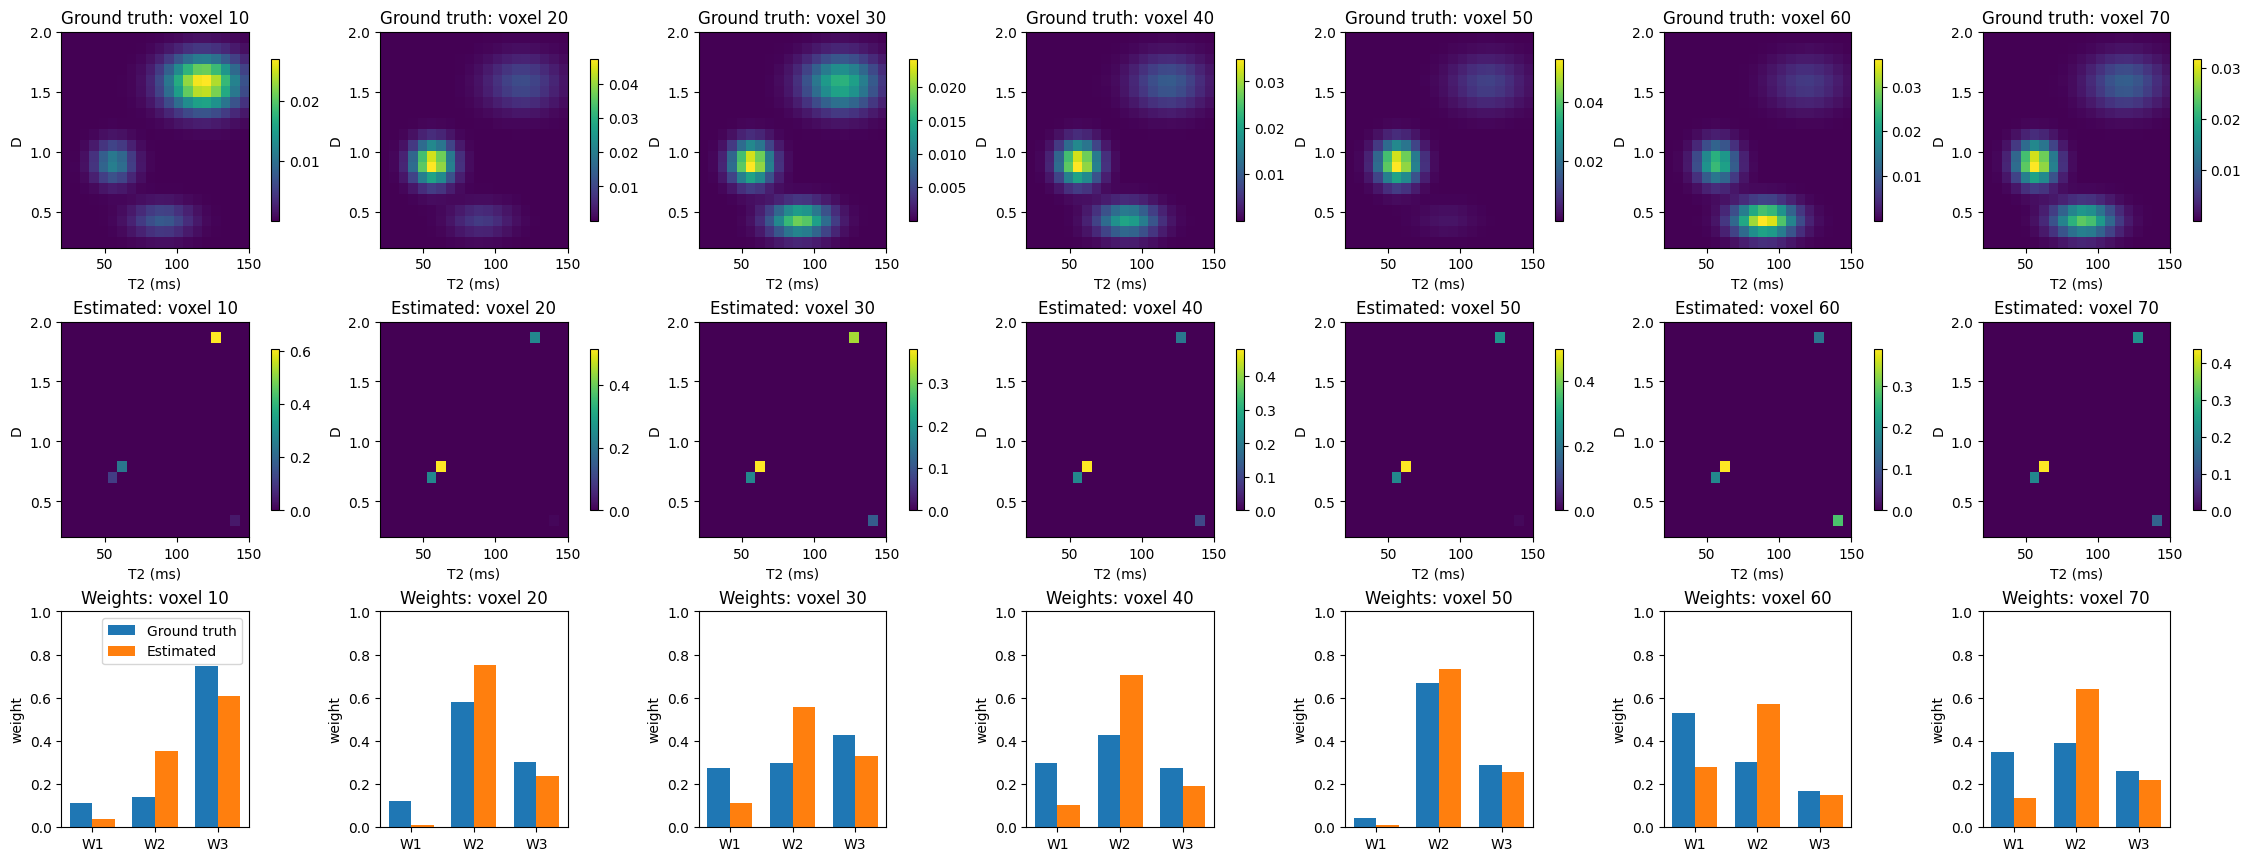

In [44]:


W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=1.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)


#### This looks pretty good
Some notes:

We have simplex constraints on C and W.
C is shared across voxels making it heirarchical
Initialisation of C, M0 and W is good, giving a very good baseline.
You can make C smoother or sparser by adding additional constraints.

You do not need a Dirichlet prior on W for this to be described as a hierarchical Bayesian MAP model.
With:
alpha = 1.0
update_alpha_flag = False
The weight prior is effectively uniform over the simplex. That is a valid weak prior and is a good baseline for basic recovery.

You can set weight_entropy>0 to make W have a sparist-favouring prior. This might be helpful for harder optimisations.

m0_prior = M0_init
m0_prior_sigma = 0.15
<-- This sets M0 to be around an initial value which is estimated using a monoexpoential fit. sigma gives the spread around the initial value


Maria's note: Sparsity also has little effect, since the spectra are already spikes. The weights are unchanged


# 2. How about estimating C_small

iter 0: loss=1744.5326, fit_err=129591.767374, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=1720.2032, fit_err=127844.539062, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=1710.1386, fit_err=127120.813554, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=1705.6936, fit_err=126801.134515, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=1703.6696, fit_err=126655.554862, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=1702.6374, fit_err=126581.305764, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=1702.0249, fit_err=126537.233849, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=1701.6094, fit_err=126507.331927, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=1701.2998, fit_err=126485.053539, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=1701.0544, fit_err=126467.390254, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=1700.8510, fit_err=126452.745581, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

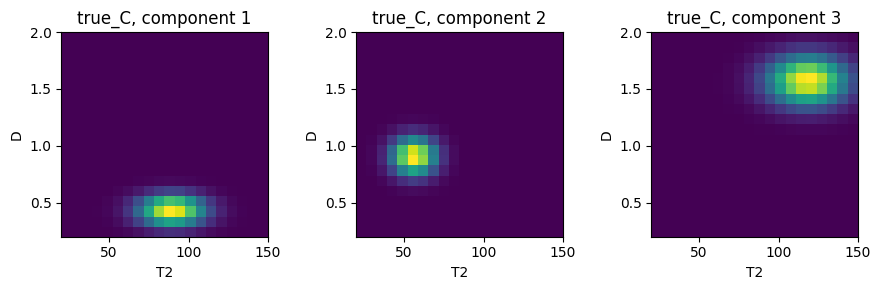

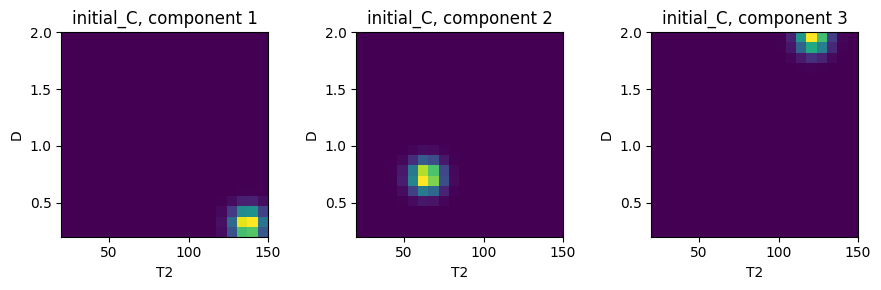

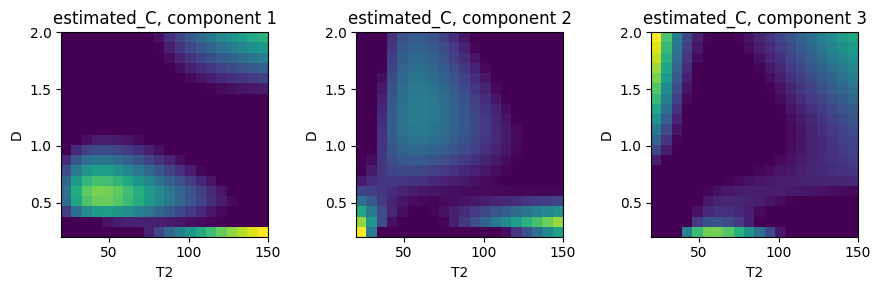

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [319.00339775 297.09742598 289.9442304  314.11911331 312.4012113
 282.6822092  301.61300457 280.98581256 291.72383831 289.67092648
 306.24739111 295.99990605 295.56826164 276.14555263 296.26906047
 283.2846576  307.1383008  318.58430345 272.67219952 294.11317167
 297.44432443 301.67044545 294.55411974 284.39363146 290.37816145
 287.98532389 279.85565039 282.77899419 282.66016651 294.40645826
 297.36794685 292.74315308 280.32413086 302.00725104 290.39160833
 298.24833908 282.35637686 308.78420904 276.2233656  267.19978026
 302.75265397 295.57966191 312.14570584 302

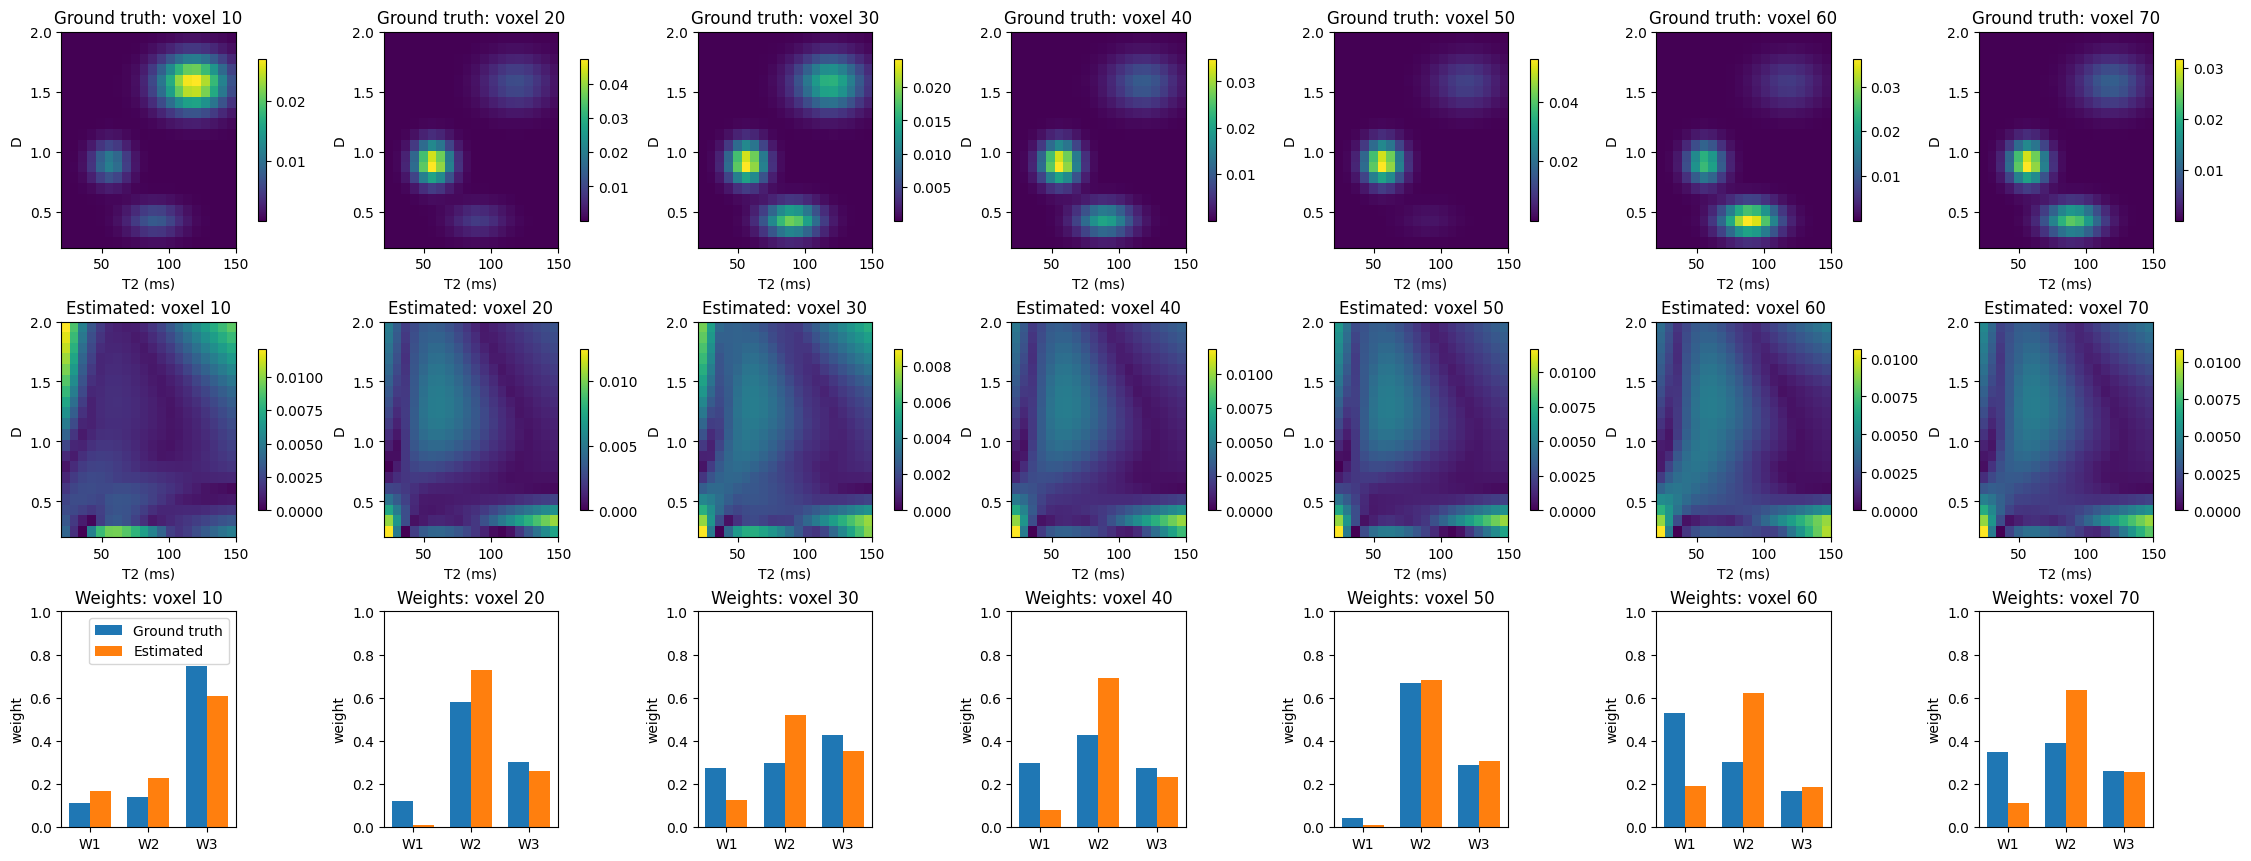

In [45]:
# CODE AT THE TOP HERE SO YOU CAN TRY DIFFERENT RANKS
R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


# Here we use run_optimisation not run_optimisation_constrained 
W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)

C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)




#### The spectra are a bit dodgy - can change R to adjust this, but the weights actually look quite good regardless. Could fit peaks afterwards?

Maria's note: Agreed. The C_small spectra are smooth but spread mass across the grid, while the weights stay good. Fitting peak positions afterwards looks like the right next step.


## 3. What happens if you set a Drichilet prior and try to estimate W and C_small?
Trying to recreate Maria's issues

iter 0: loss=1744.5326, fit_err=129591.767374, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=1720.2032, fit_err=127844.539062, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=1710.1386, fit_err=127120.813554, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=1705.6936, fit_err=126801.134515, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=1703.6696, fit_err=126655.554862, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=1699.7736, fit_err=126581.305764, sigma2=36.000000, lam=0.0000, alpha=1.2722
iter 6: loss=1698.7114, fit_err=126526.603043, sigma2=36.000000, lam=0.0000, alpha=1.2891
iter 7: loss=1697.9923, fit_err=126491.756002, sigma2=36.000000, lam=0.0000, alpha=1.3018
iter 8: loss=1697.4522, fit_err=126466.915023, sigma2=36.000000, lam=0.0000, alpha=1.3122
iter 9: loss=1697.0192, fit_err=126447.743713, sigma2=36.000000, lam=0.0000, alpha=1.3209
iter 10: loss=1696.6562, fit_err=126432.110571, sigma2=36.000000, lam=0.0000, alpha=1.3285
iter 11: 

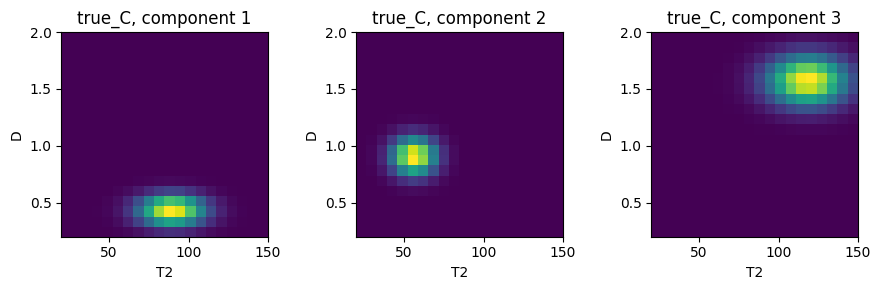

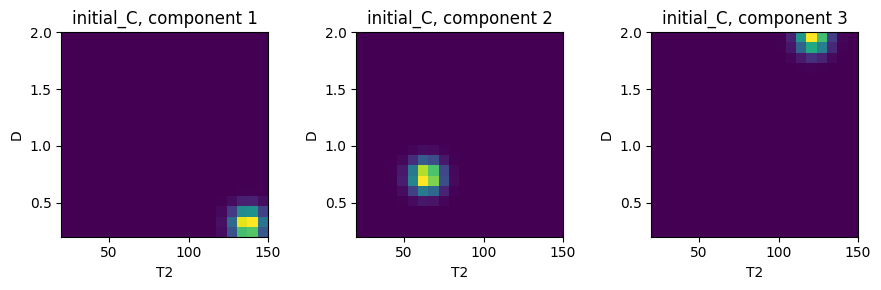

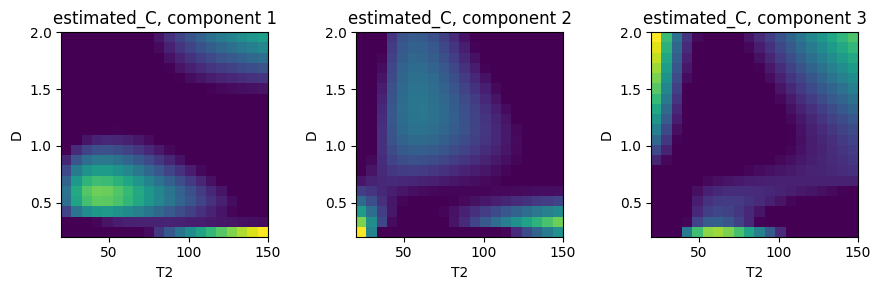

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [319.00316358 297.09721166 289.9439495  314.11818067 312.40113061
 282.68205288 301.61273954 280.98565061 291.72371822 289.67062709
 306.24745281 296.00003731 295.56812353 276.14633657 296.26903084
 283.28475058 307.13781741 318.58398034 272.67212602 294.11290602
 297.4448507  301.67015276 294.55405047 284.39461333 290.37790941
 287.98523098 279.85510092 282.77898014 282.66007718 294.40629901
 297.36767583 292.74329364 280.32377884 302.00680877 290.39177807
 298.2484688  282.35655553 308.78450607 276.22318737 267.19980597
 302.75217963 295.57965765 312.14382155 30

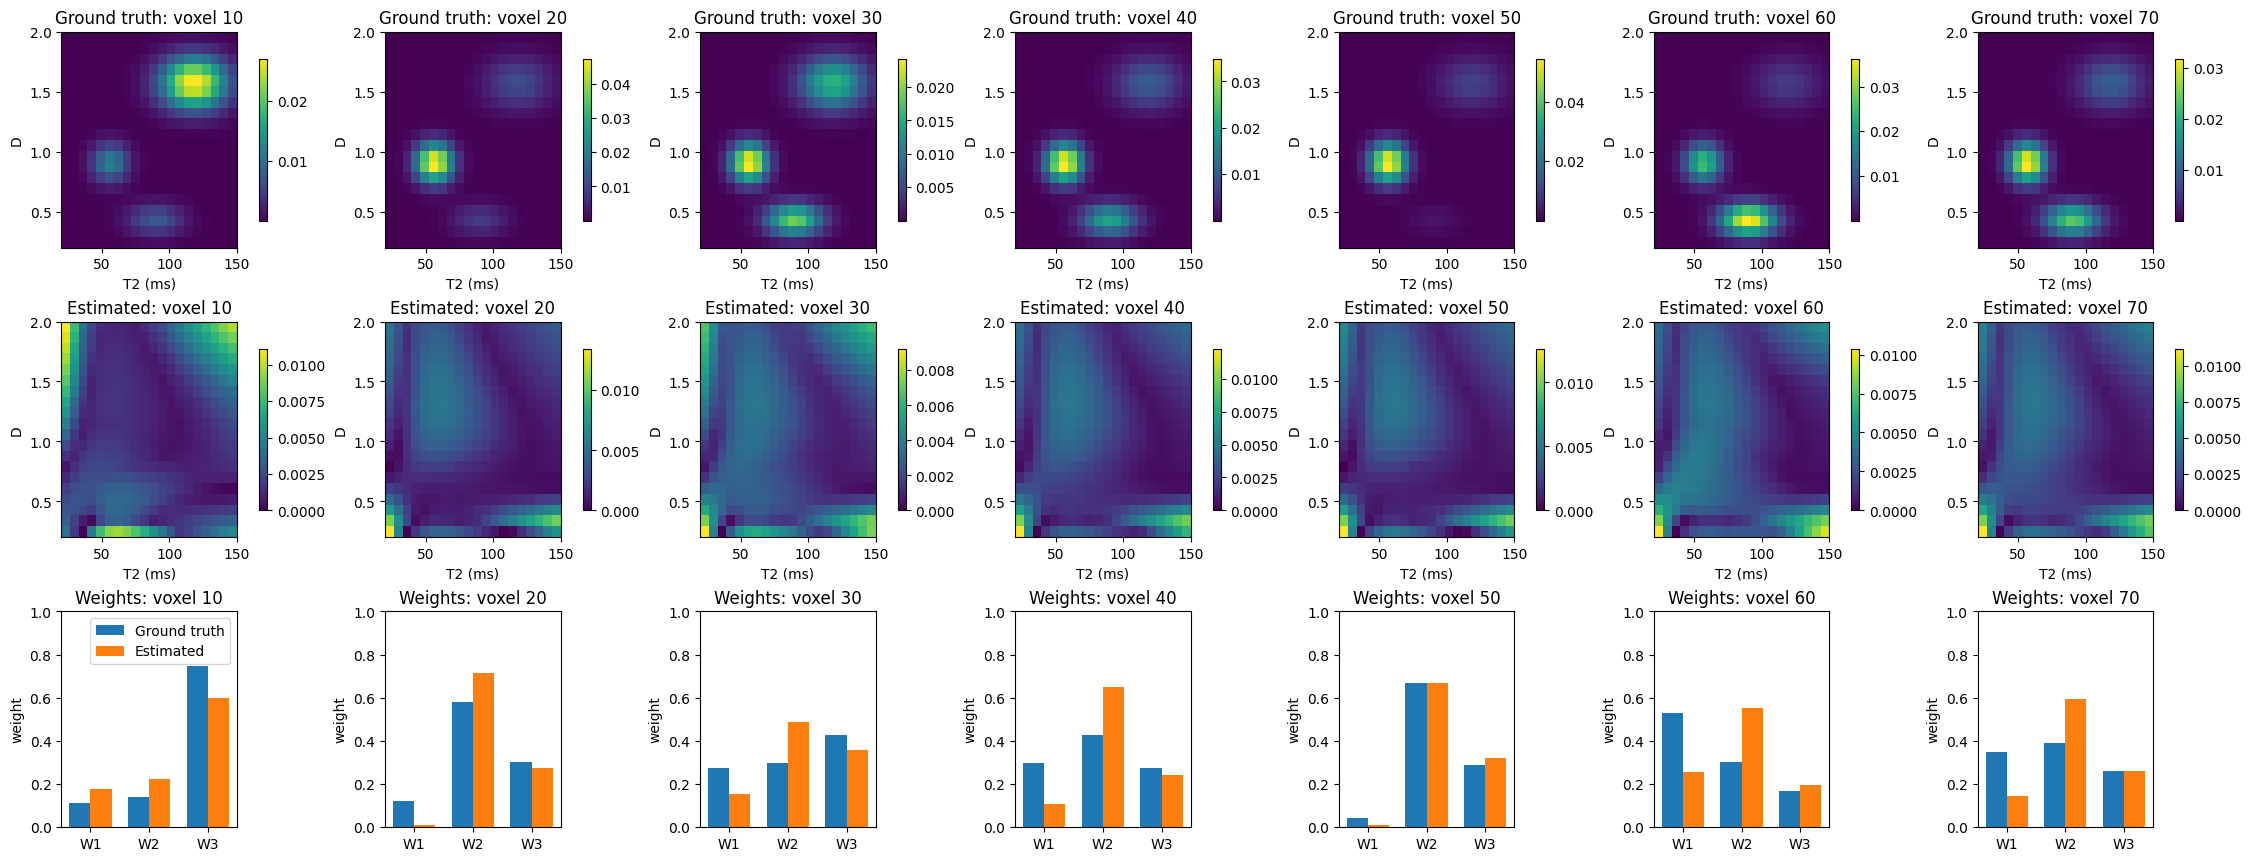

In [46]:
# 

R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

print("W MAE:", np.mean(np.abs(W_true - W_est)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est)))
print("C MAE:", np.mean(np.abs(C_true - C_est)))
print("alpha:", alpha_est)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])

print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show)




#### This also seems to work - our spectra are blurred but we recover the wieghts well and we can postprocess the spectra. 

Note, the GT fibre fractions are not drawn from a Dirichlet distribution, do there is no "GT" alpha, but this optimisation uses Dirichlet as a regulariser.

Maria's note: A learned alpha below one favours sparse weights and above one favours even weights. Here alpha moves above one, which matches the fairly even true weights and the weights are still recovered well


### Let's try with a GT alpha to see if we can recover this also

Maria's note: This cell only runs the initialisation, to check the starting spectra. The data now has sparse weights drawn from a Dirichlet distribution with a known alpha. The next cell repeats this and runs the optimisation


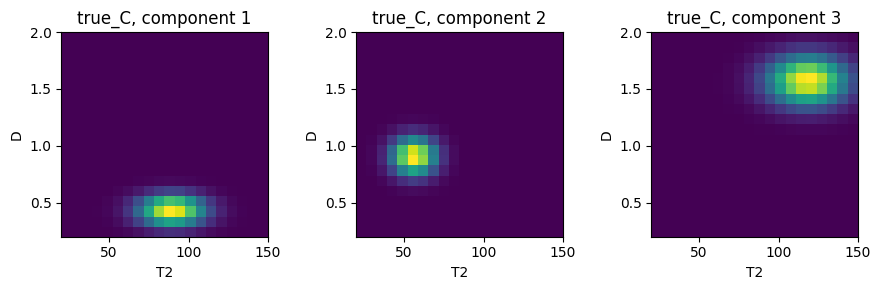

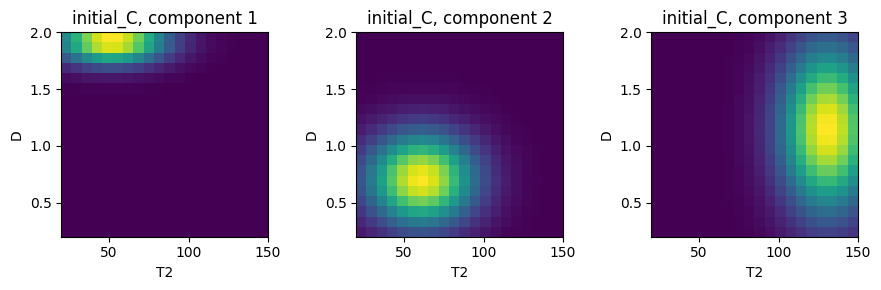

In [47]:
alpha_true = 0.5
rng_d = np.random.default_rng(0) #rng_d has to be defined again to get the same results!
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])

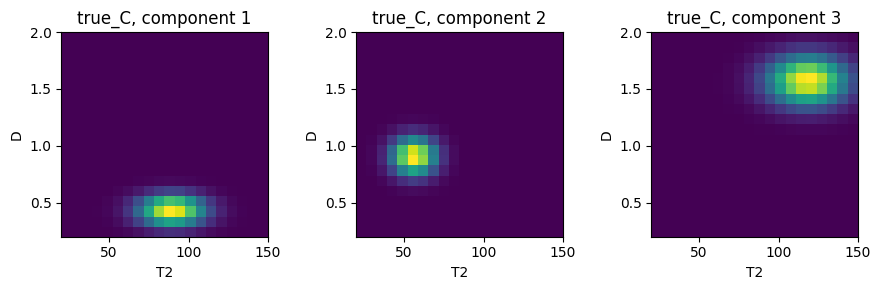

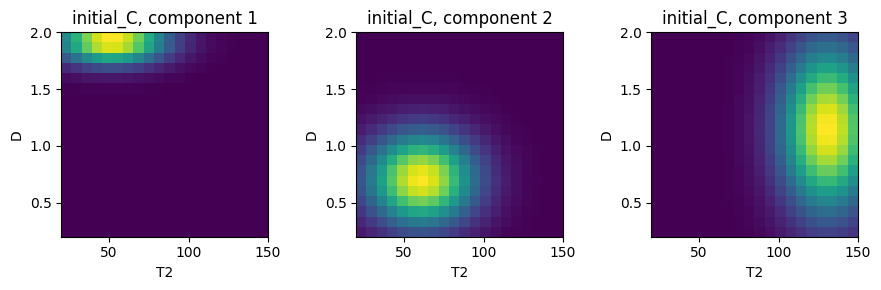

iter 0: loss=3563.5168, fit_err=260493.957987, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2896.2018, fit_err=212463.617938, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2864.8640, fit_err=210208.405668, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2858.0732, fit_err=209721.810551, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2850.8454, fit_err=209205.184782, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2828.0427, fit_err=208457.185982, sigma2=36.000000, lam=0.0000, alpha=0.6532
iter 6: loss=2812.7243, fit_err=207362.813781, sigma2=36.000000, lam=0.0000, alpha=0.6527
iter 7: loss=2790.6663, fit_err=205787.109857, sigma2=36.000000, lam=0.0000, alpha=0.6519
iter 8: loss=2760.1228, fit_err=203607.595372, sigma2=36.000000, lam=0.0000, alpha=0.6501
iter 9: loss=2720.1137, fit_err=200756.389498, sigma2=36.000000, lam=0.0000, alpha=0.6470
iter 10: loss=2671.3553, fit_err=197288.421036, sigma2=36.000000, lam=0.0000, alpha=0.6421
iter 11: 

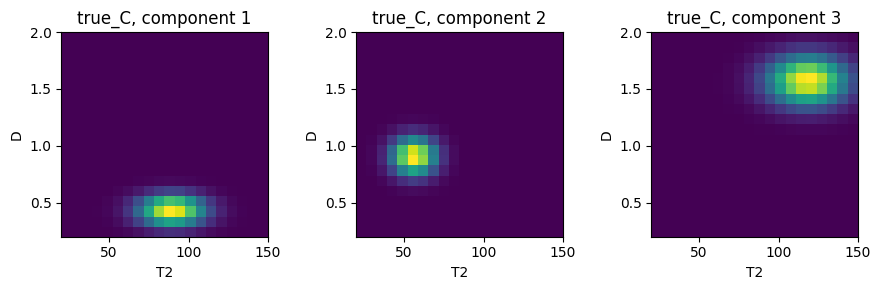

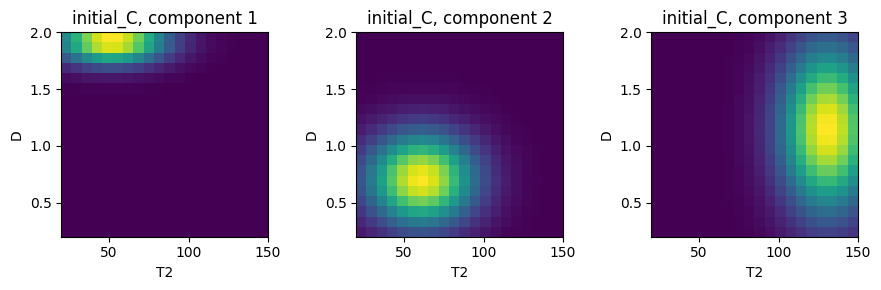

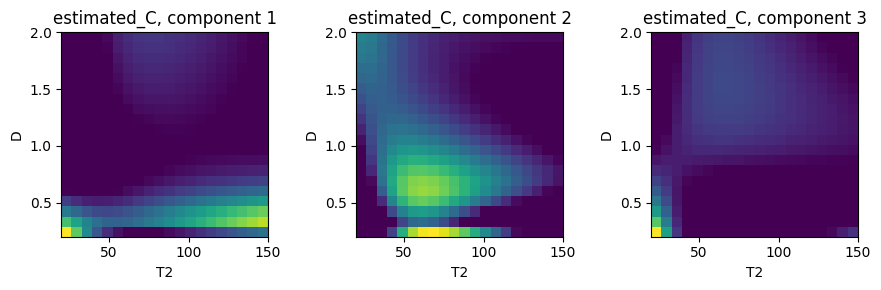

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [308.87928504 289.07867956 279.08417992 307.15319767 312.2720279
 297.24739094 289.59979838 289.87274588 286.13127999 294.29472018
 284.31653579 319.60362576 305.60084491 299.87594024 295.51845391
 321.15209356 307.95964052 292.39262981 293.35439159 307.96936287
 286.1224376  308.43824612 292.11363431 308.50770548 291.81598478
 287.14594442 304.36211787 303.24559356 278.70243598 293.8014144
 299.73039721 309.45654295 303.85628386 300.25225504 297.38121362
 325.87888949 302.49146248 295.77205817 309.55524256 292.68234996
 286.43595764 277.27500131 270.92322535 293.

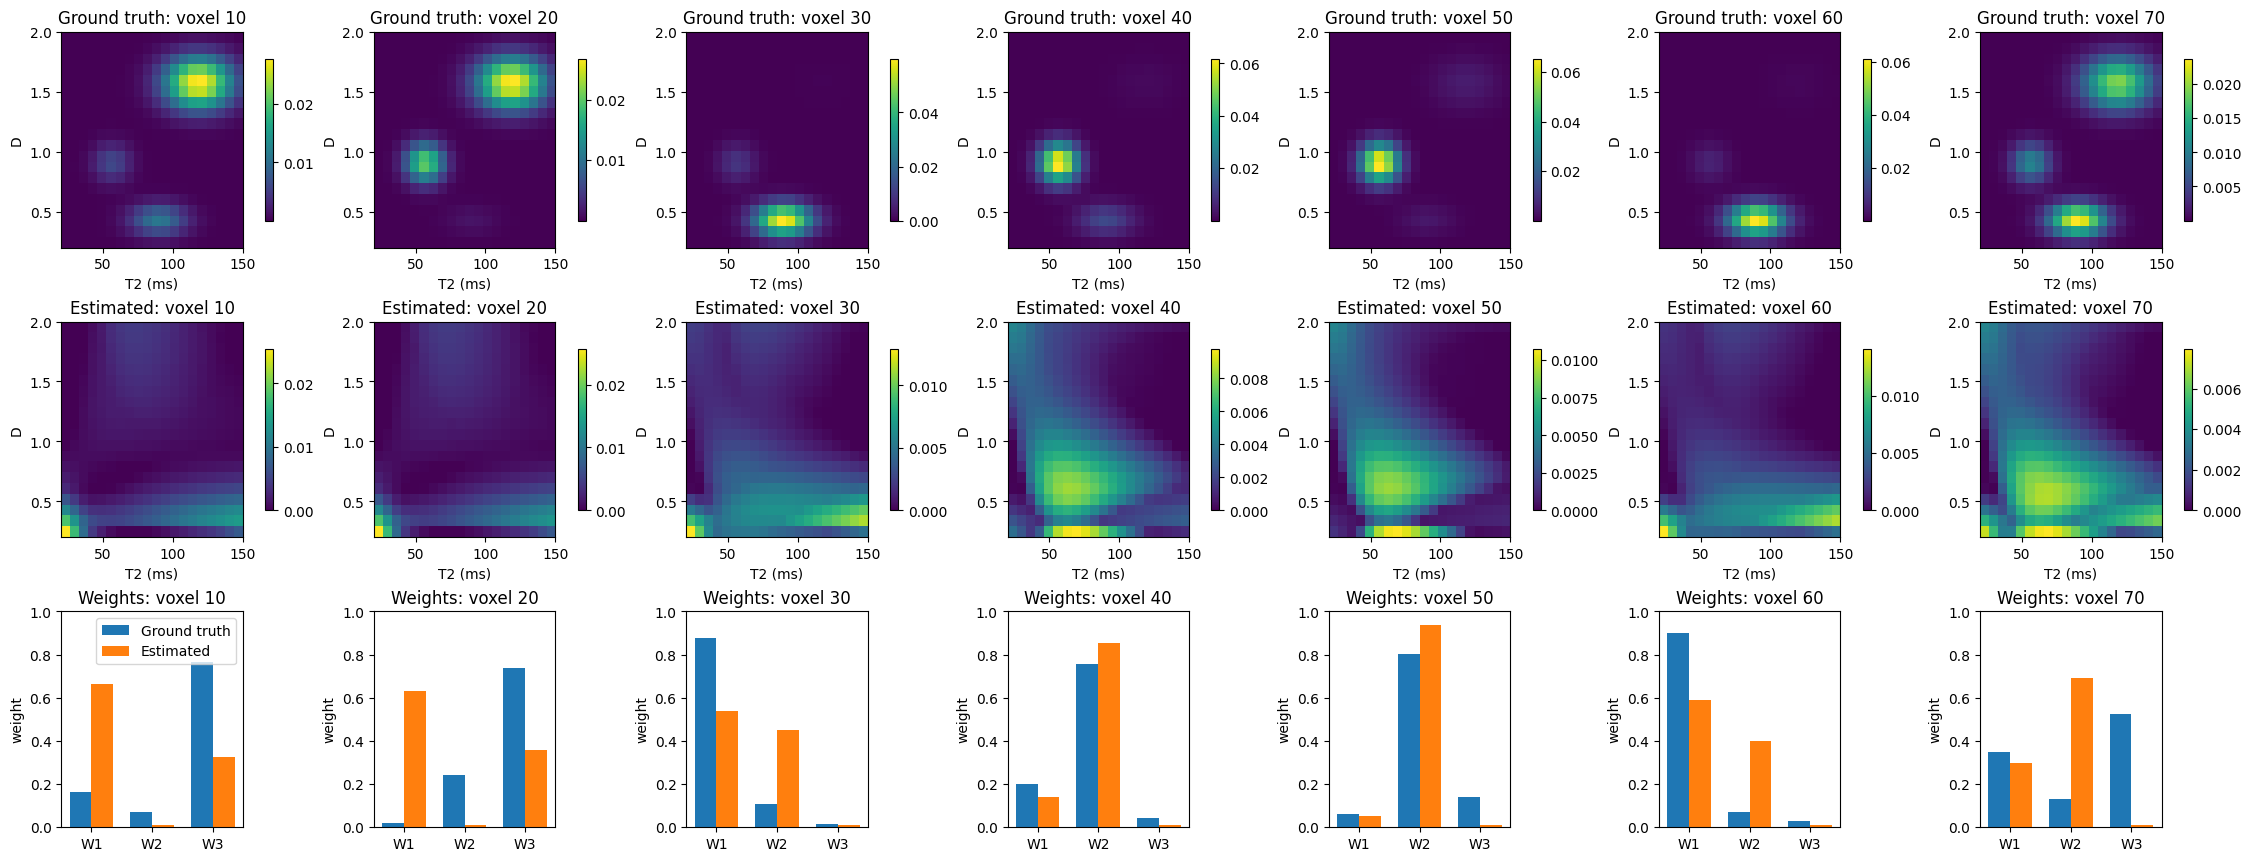

In [48]:
alpha_true = 0.5
rng_d = np.random.default_rng(0)
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est_dirichlet, M0_est_dirichlet, Csmall_est_dirichlet, alpha_est_dirichlet, sigma2_est_dirichlet, lam_est_dirichlet, losses_dirichlet, fit_errs_dirichlet = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here
        
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est_dirichlet = estimate_C(Vmat, s, Csmall_est_dirichlet)
C_est_dirichlet, W_est_dirichlet = order_components(C_true, C_est_dirichlet, W_est_dirichlet, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est_dirichlet @ W_est_dirichlet

print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est_dirichlet)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est_dirichlet)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)






#### alpha isnt reconstructed perfectly but it does track with GT (e.g. estimated=0.3 when GT=0.1, and estimated = 5 when GT=10)

This also looks reasonable

Maria's note:  With the seeded data here, alpha is recovered close to the true value and the weights are good. The spectra are still blurred and one initial component sits too high in D


## 4. An alternative to alpha

Instead of using a Dirichlet prior, we could instead have an entropy prior on the weights. With lower entropy, more voxels have sparse weights, whilst still obeying the simplex constraint.

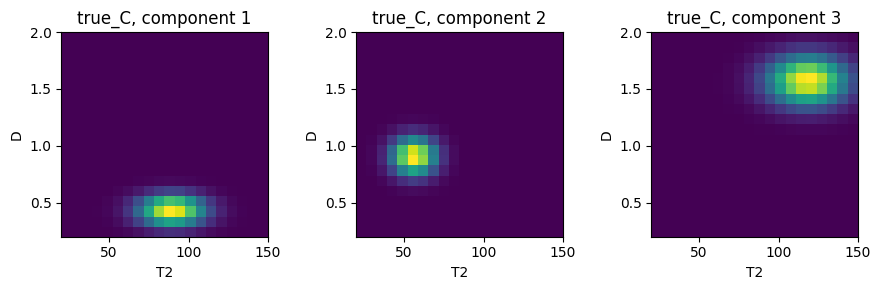

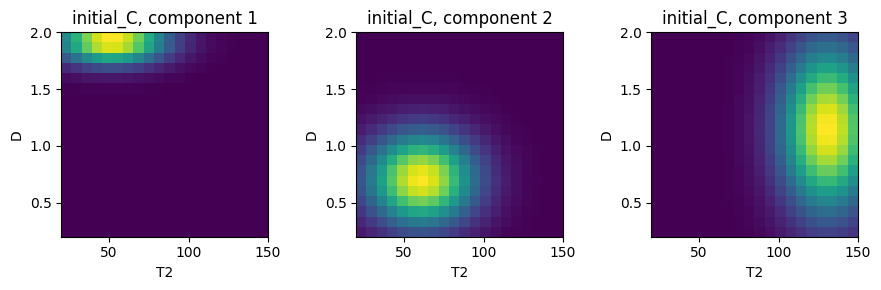

iter 0: loss=4324.3615, fit_err=275222.857601, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=3789.7543, fit_err=234746.822268, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=3767.8040, fit_err=232900.155152, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=3760.4153, fit_err=232384.030617, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=3694.3450, fit_err=227473.497292, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=3689.5963, fit_err=227232.669838, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=3682.6446, fit_err=226848.527438, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=3671.8556, fit_err=226213.191674, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=3655.0260, fit_err=225186.811419, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=3629.2528, fit_err=223590.291497, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=3591.4694, fit_err=221244.802405, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

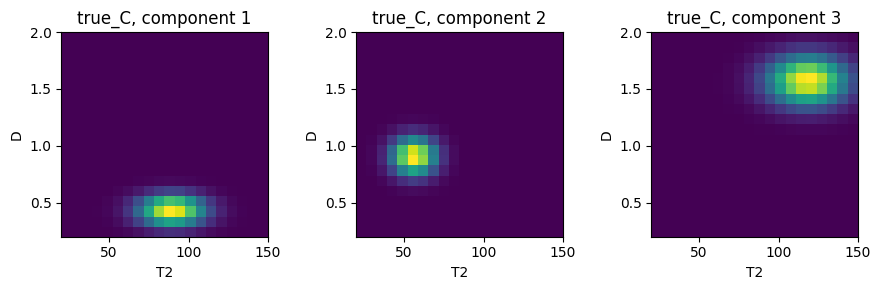

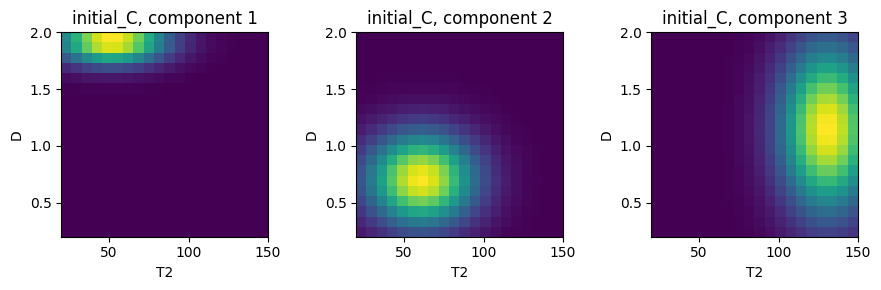

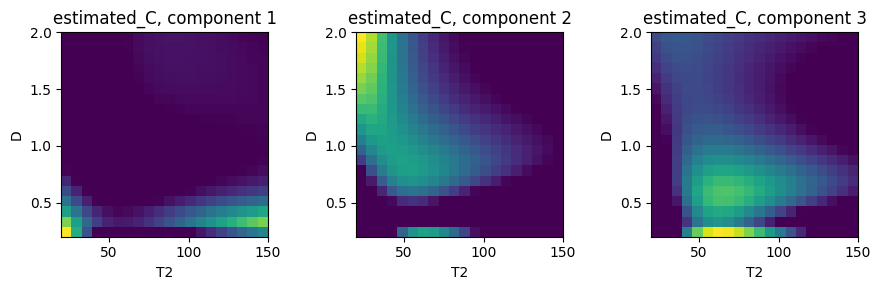

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [308.8621412  289.06223017 279.0850173  307.15645654 312.27569559
 297.21152229 289.59903222 289.87015711 286.13041905 294.30097401
 284.31432655 319.60623835 305.59922125 299.87588479 295.5164845
 321.15092969 307.95904497 292.39066577 293.35427258 307.98474378
 286.12895596 308.43005231 292.10820262 308.51908445 291.81469918
 287.14491163 304.35990813 303.24484428 278.69845483 293.80335578
 299.72873365 309.4255871  303.85624001 300.25075915 297.38873446
 325.88061056 302.4906433  295.77242936 309.5539072  292.68367162
 286.43377192 277.27397845 270.94843187 293

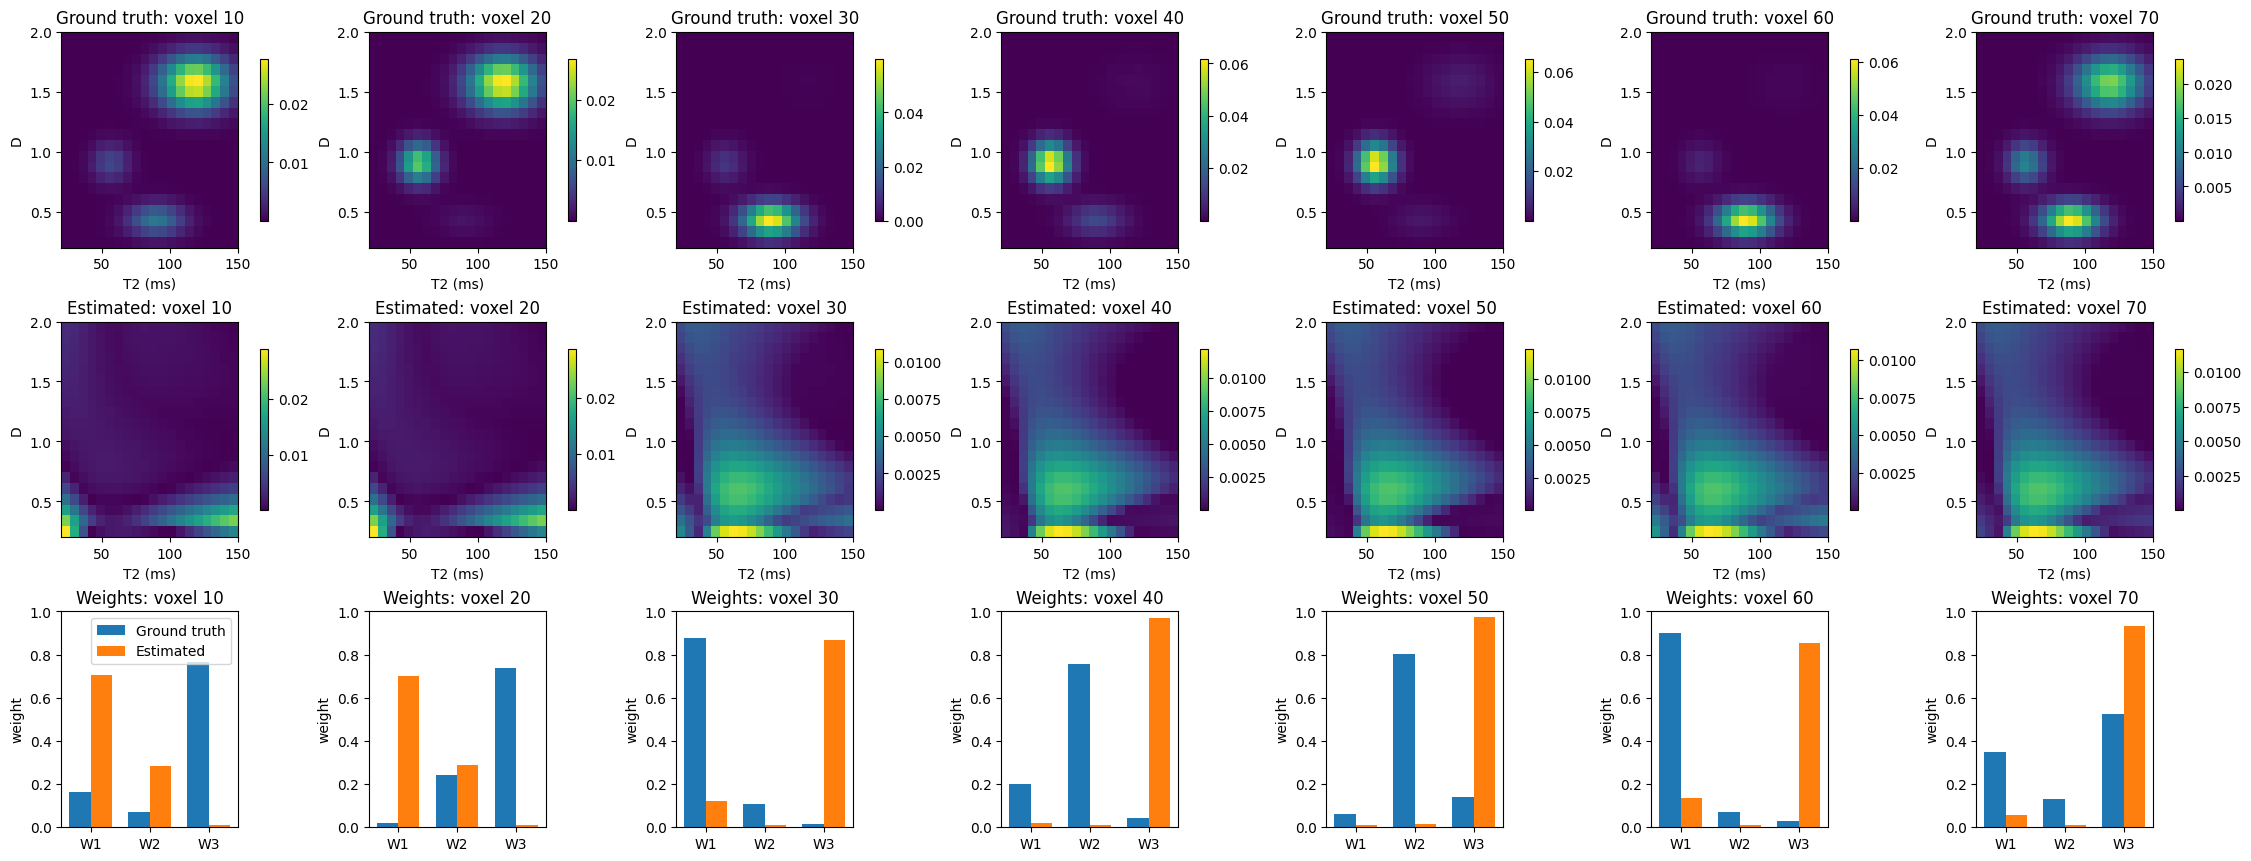

In [49]:
# Here initilise with Dirichlet-distributed weights with alpha<1 to make sparse wieghts, but optimise not assuming Dirichlet

alpha_true = 0.5
rng_d = np.random.default_rng(0)
W_true_dirichlet = rng_d.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_d)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=10.0,        

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est @ W_est

# print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
# print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
# print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
# print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est, voxels_to_show)






#### This doesnt seem to make a big difference? the weights are well estimated with entropy=0. Leaving in as an option

Maria's note: This uses the same data as the Dirichlet run above, with an entropy penalty on the weights instead of a learned alpha. The entropy prior gives almost the same weights and spectra, so it doesn't clearly help. The seed comparison below agrees.


#### I added a Dirichlet vs entropy prior over several seeds
NNLS on each voxel, then average the spectra. Each seed gives new weights and noise.

Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.264


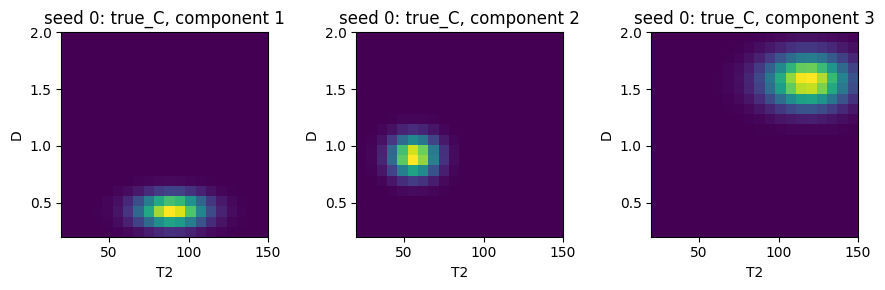

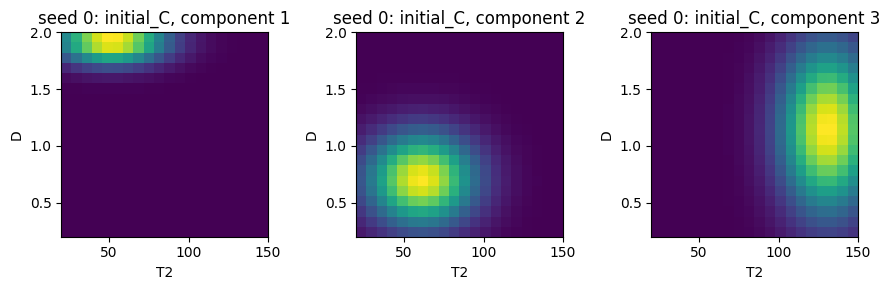



iter 0: loss=3563.5168, fit_err=260493.957987, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 0, dirichlet prior: estimated C, W MAE 0.240


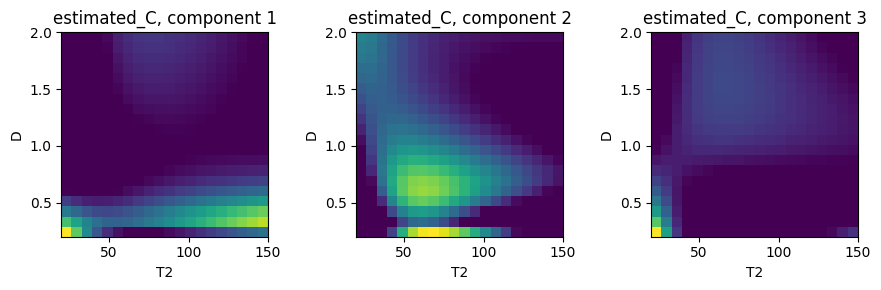

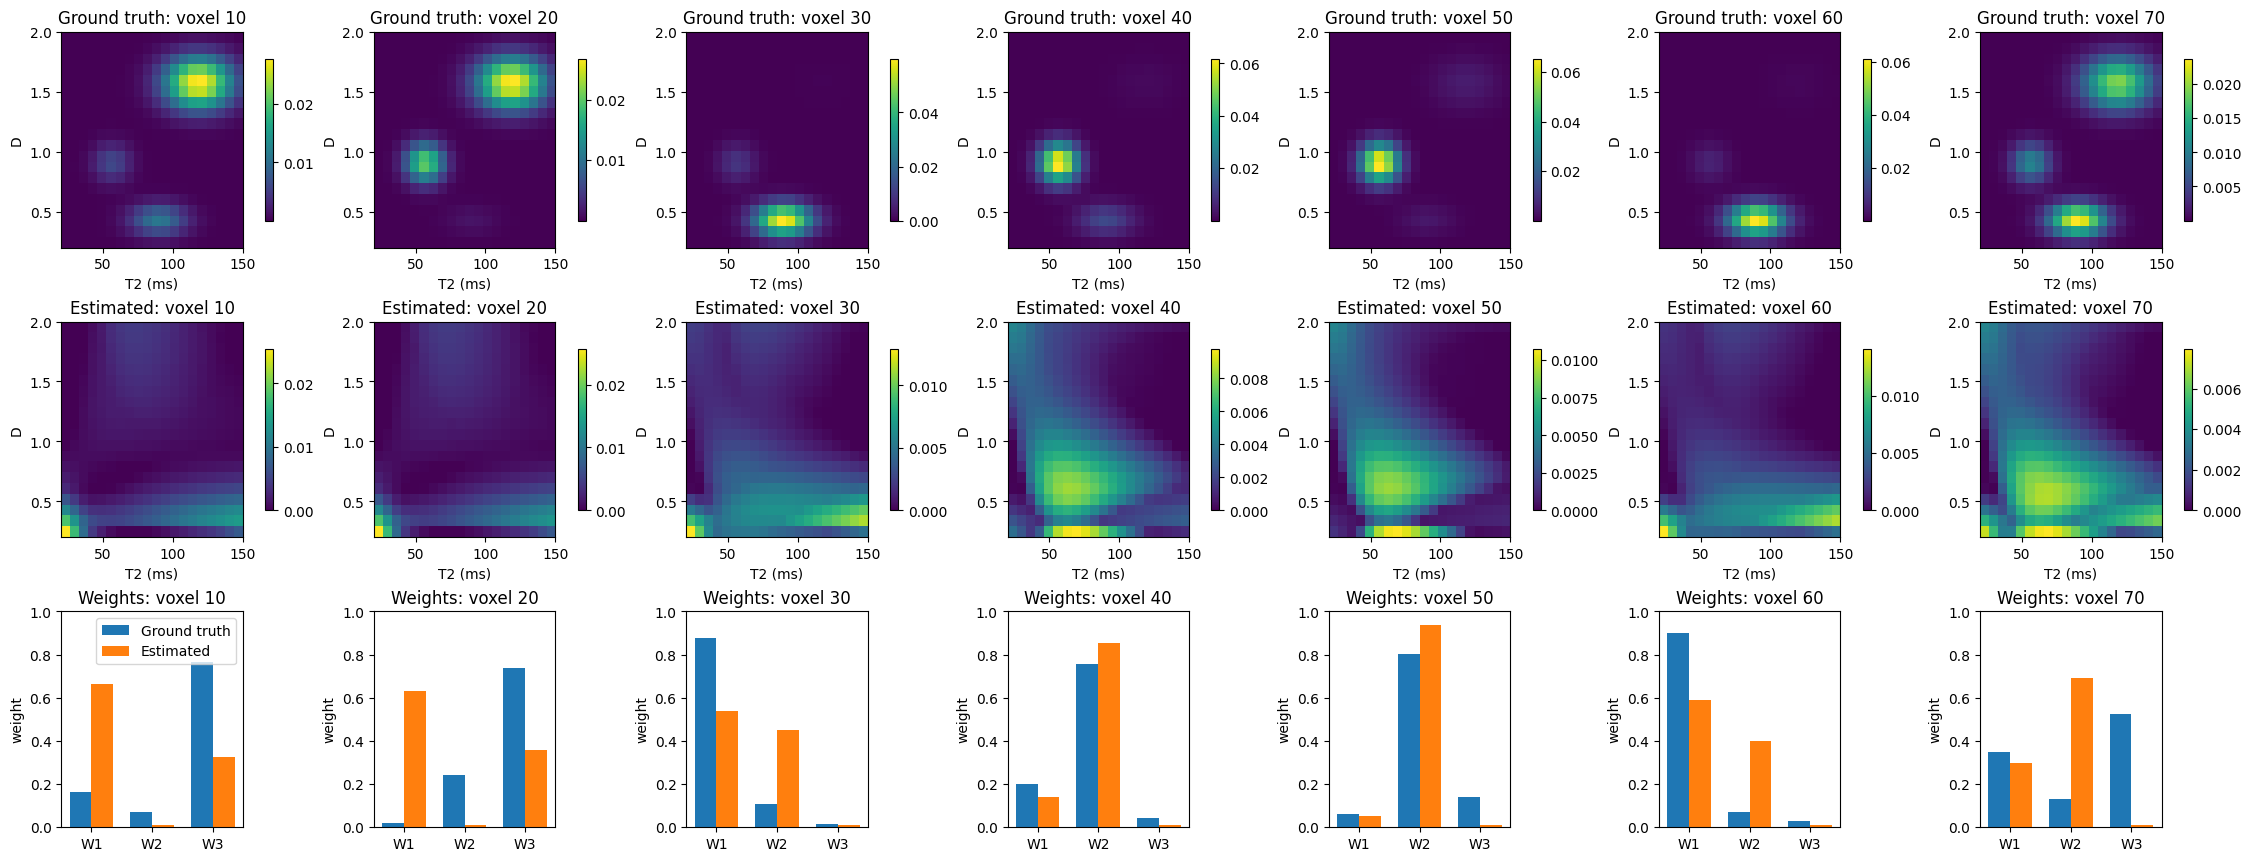

iter 0: loss=4324.3615, fit_err=275222.857601, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 0, entropy prior: estimated C, W MAE 0.480


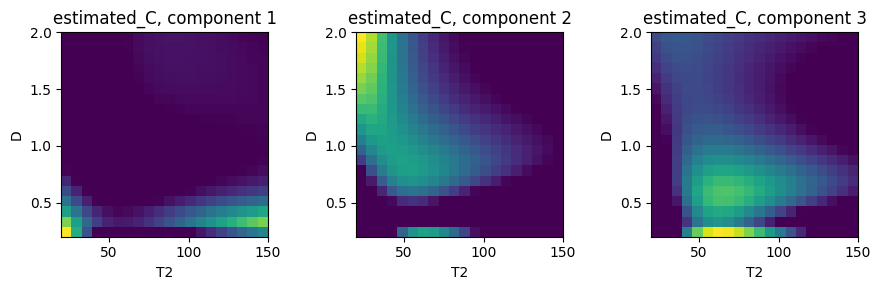

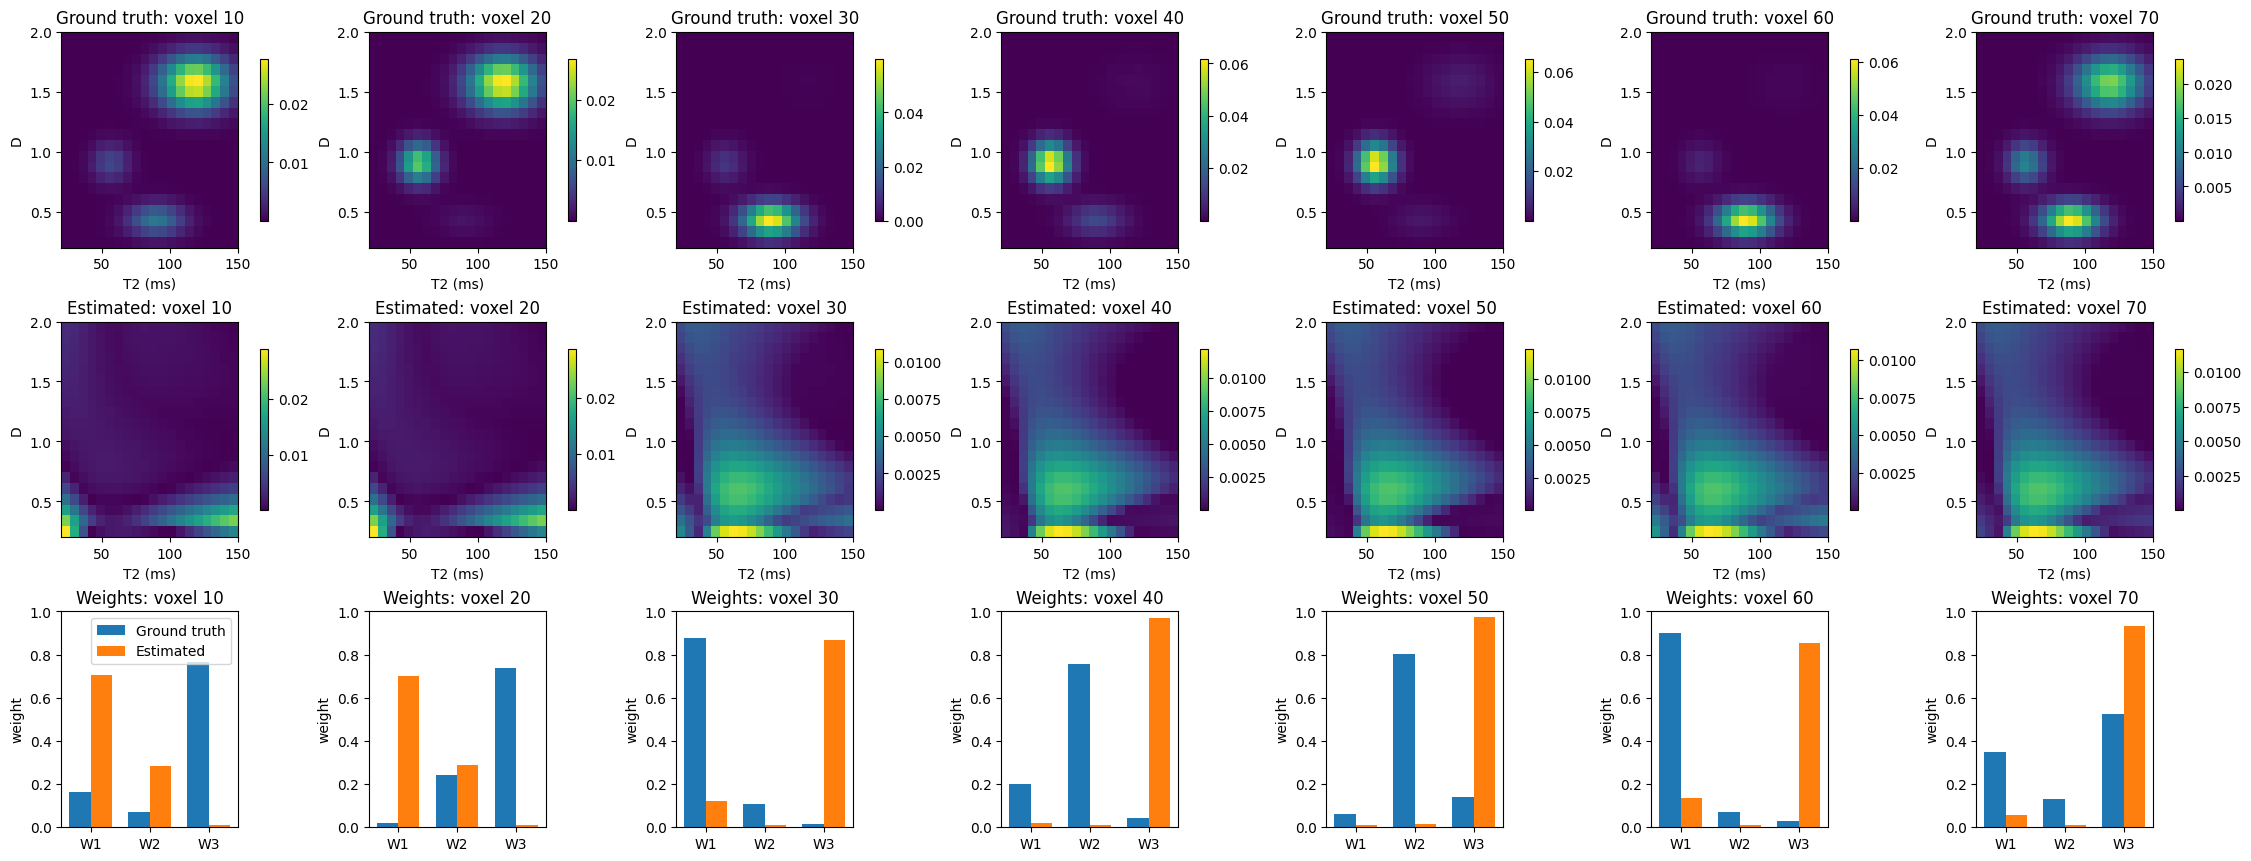

Seed 1: true C (first row) vs initial C (second row), starting W MAE 0.301


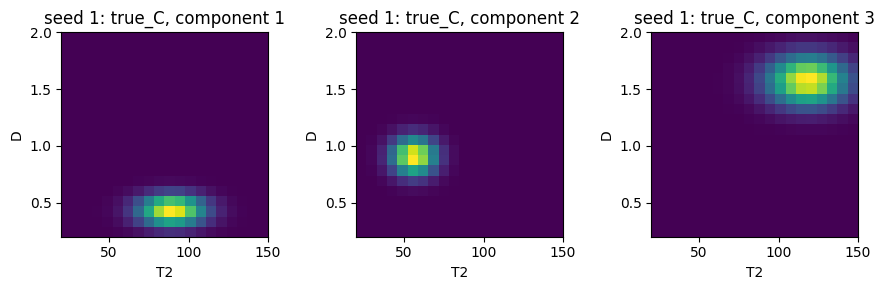

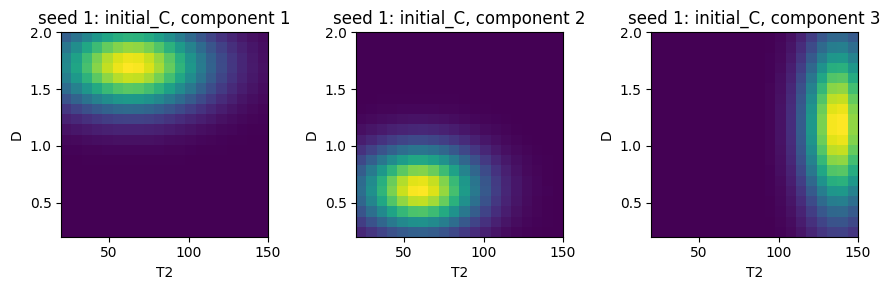



iter 0: loss=3006.4646, fit_err=220364.715842, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 1, dirichlet prior: estimated C, W MAE 0.155


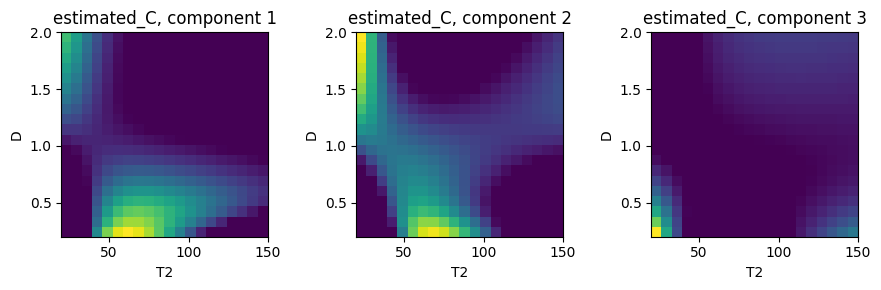

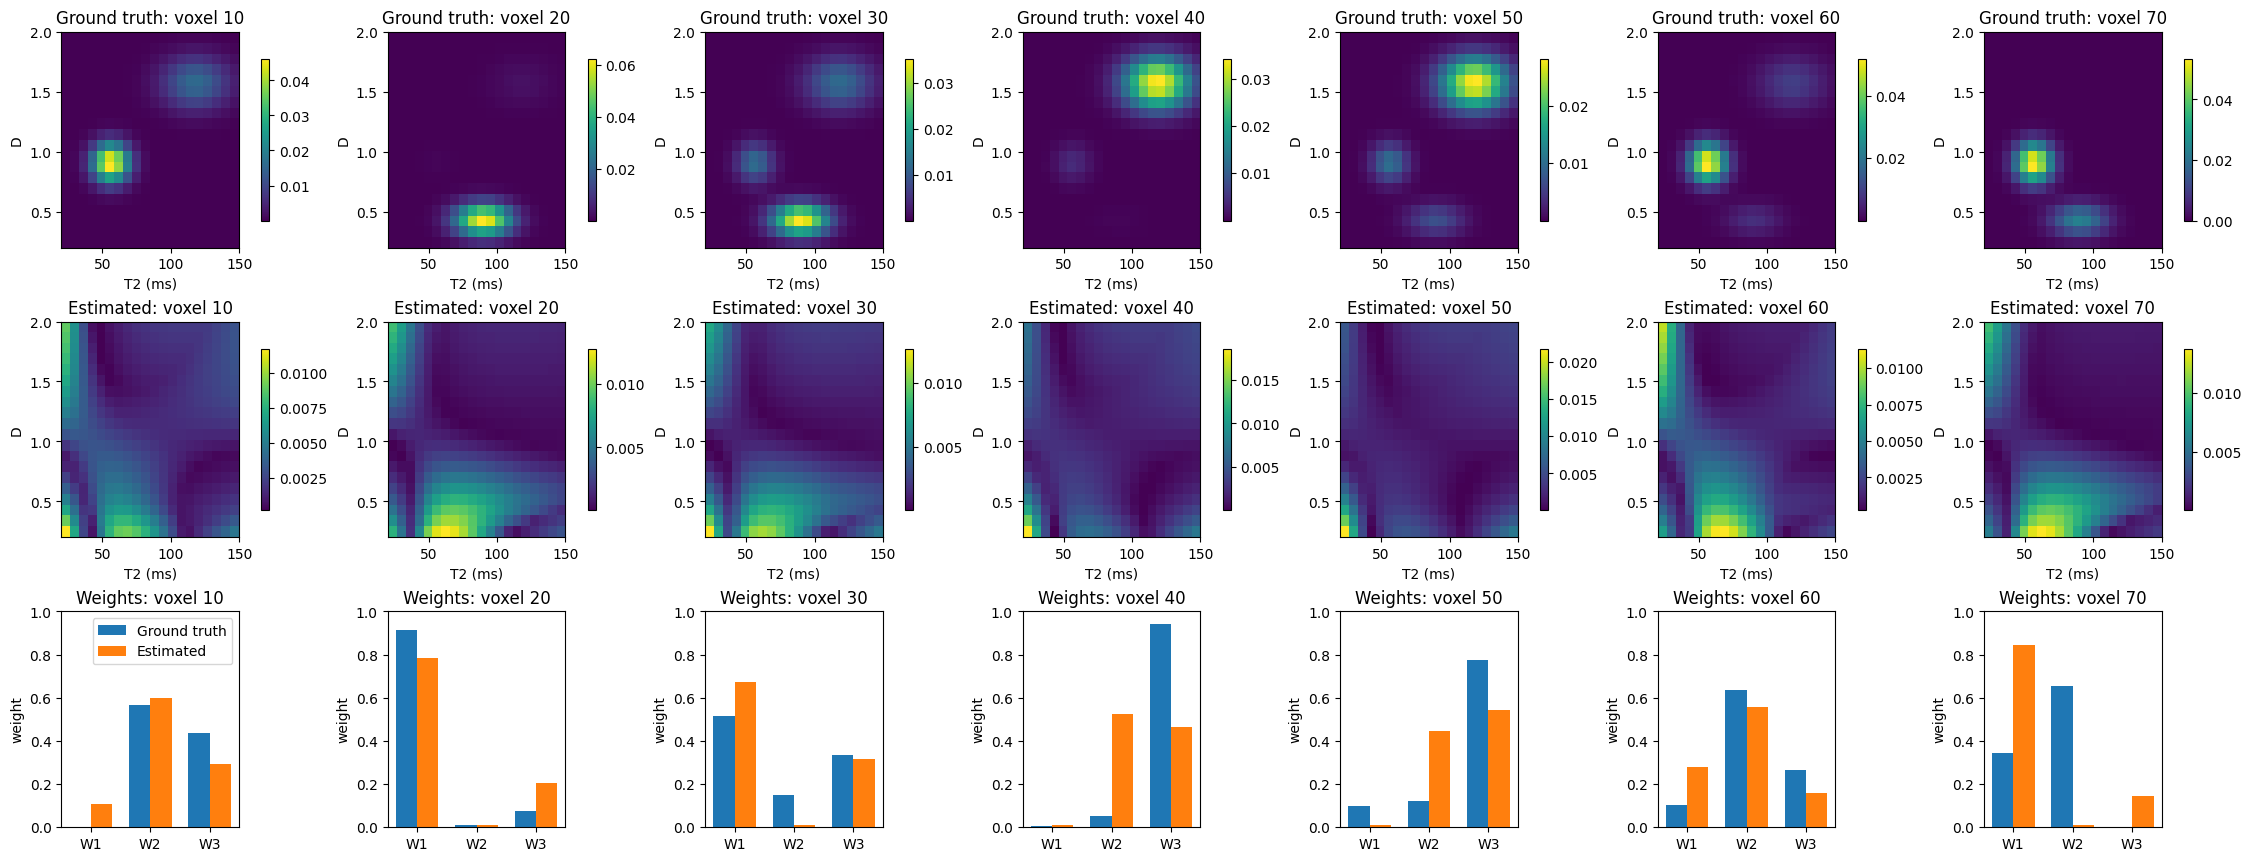

iter 0: loss=3737.8387, fit_err=231354.982029, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 1, entropy prior: estimated C, W MAE 0.108


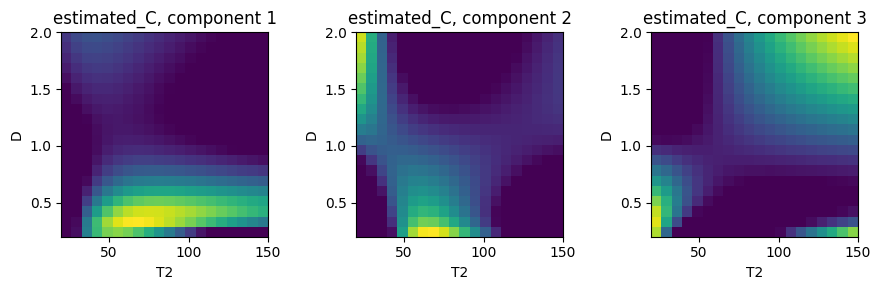

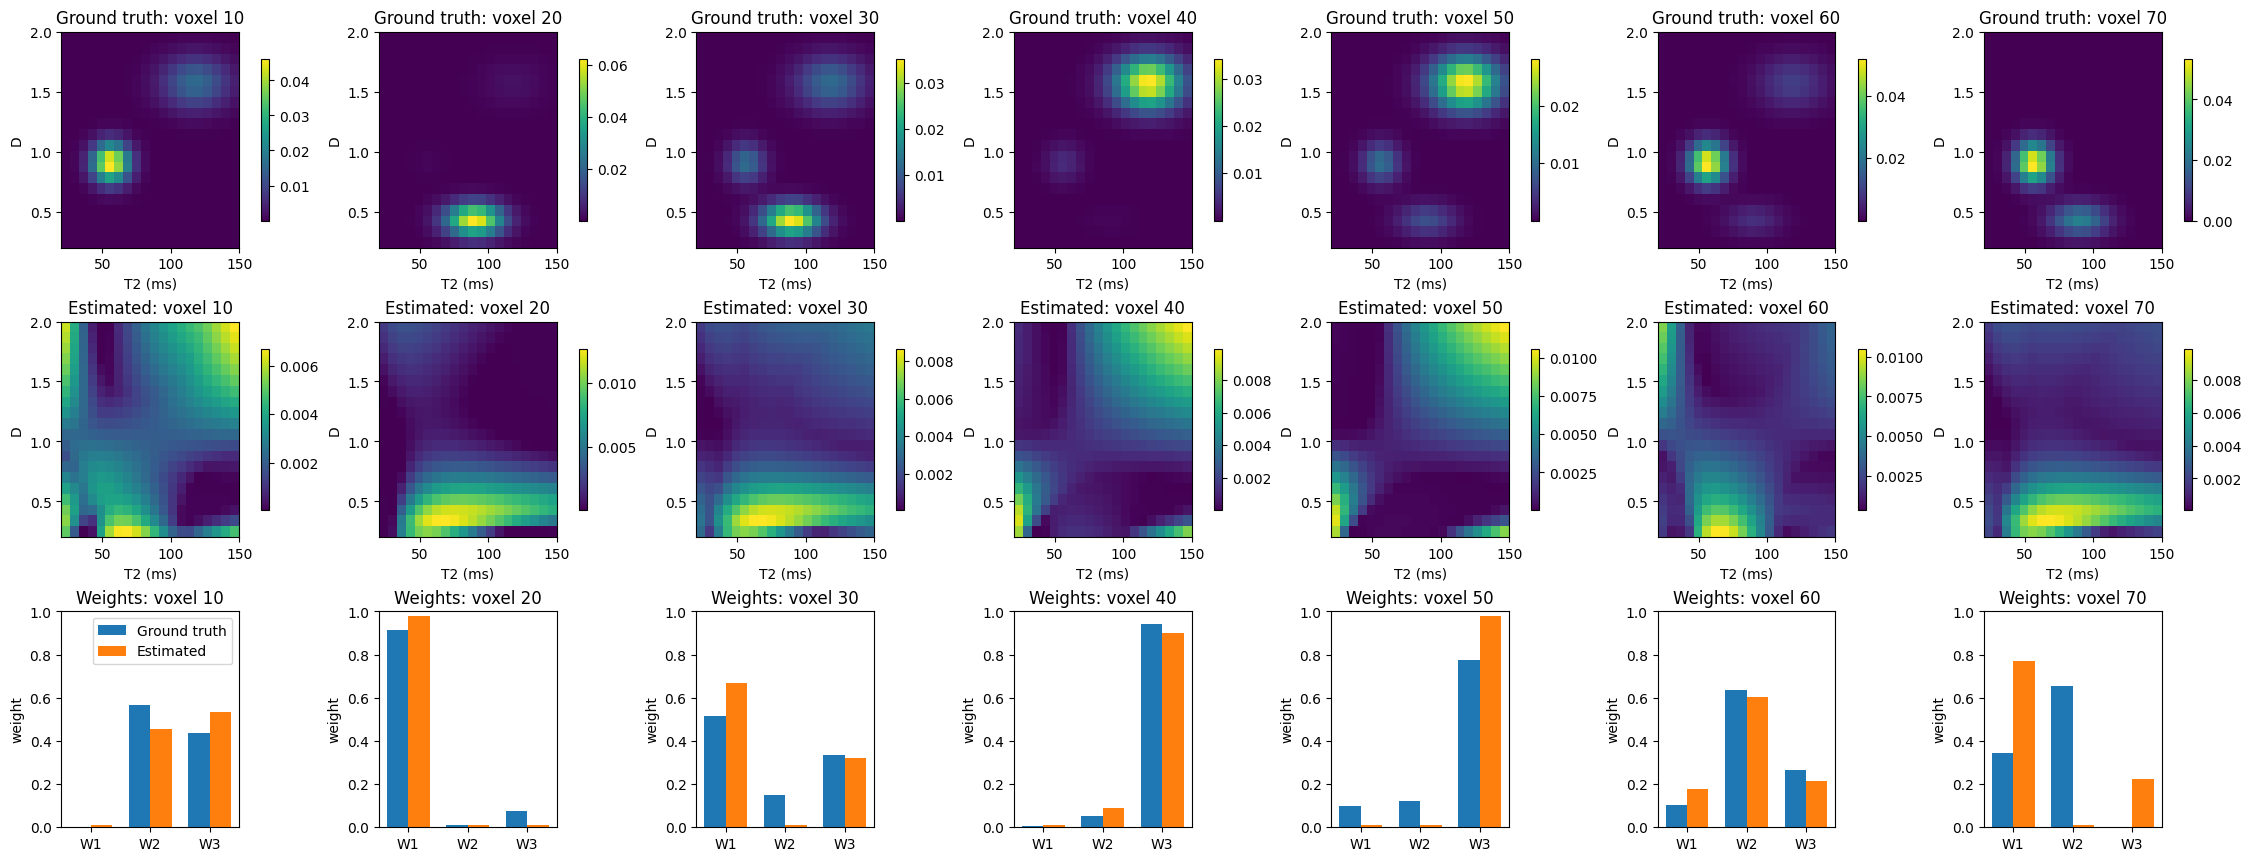

Seed 2: true C (first row) vs initial C (second row), starting W MAE 0.261


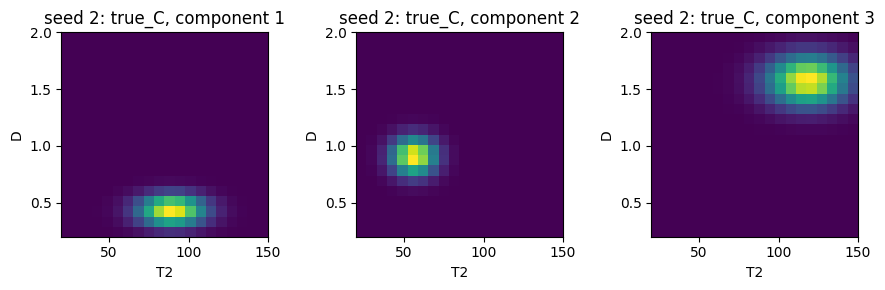

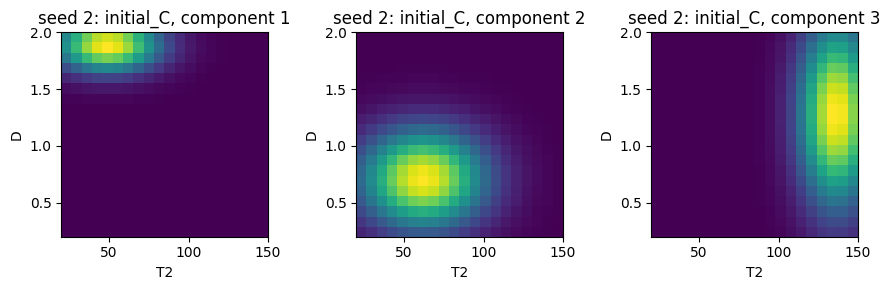



iter 0: loss=3623.5044, fit_err=264790.734833, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 2, dirichlet prior: estimated C, W MAE 0.127


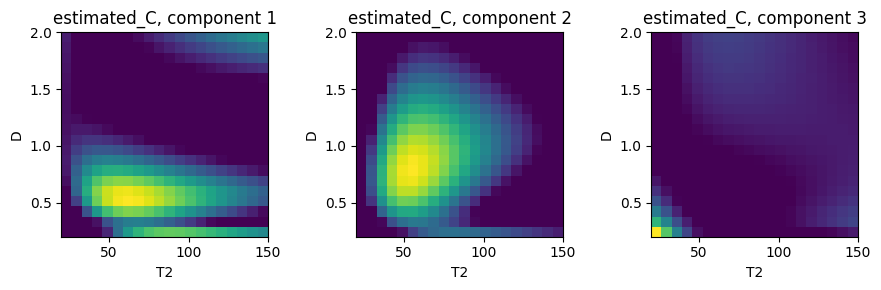

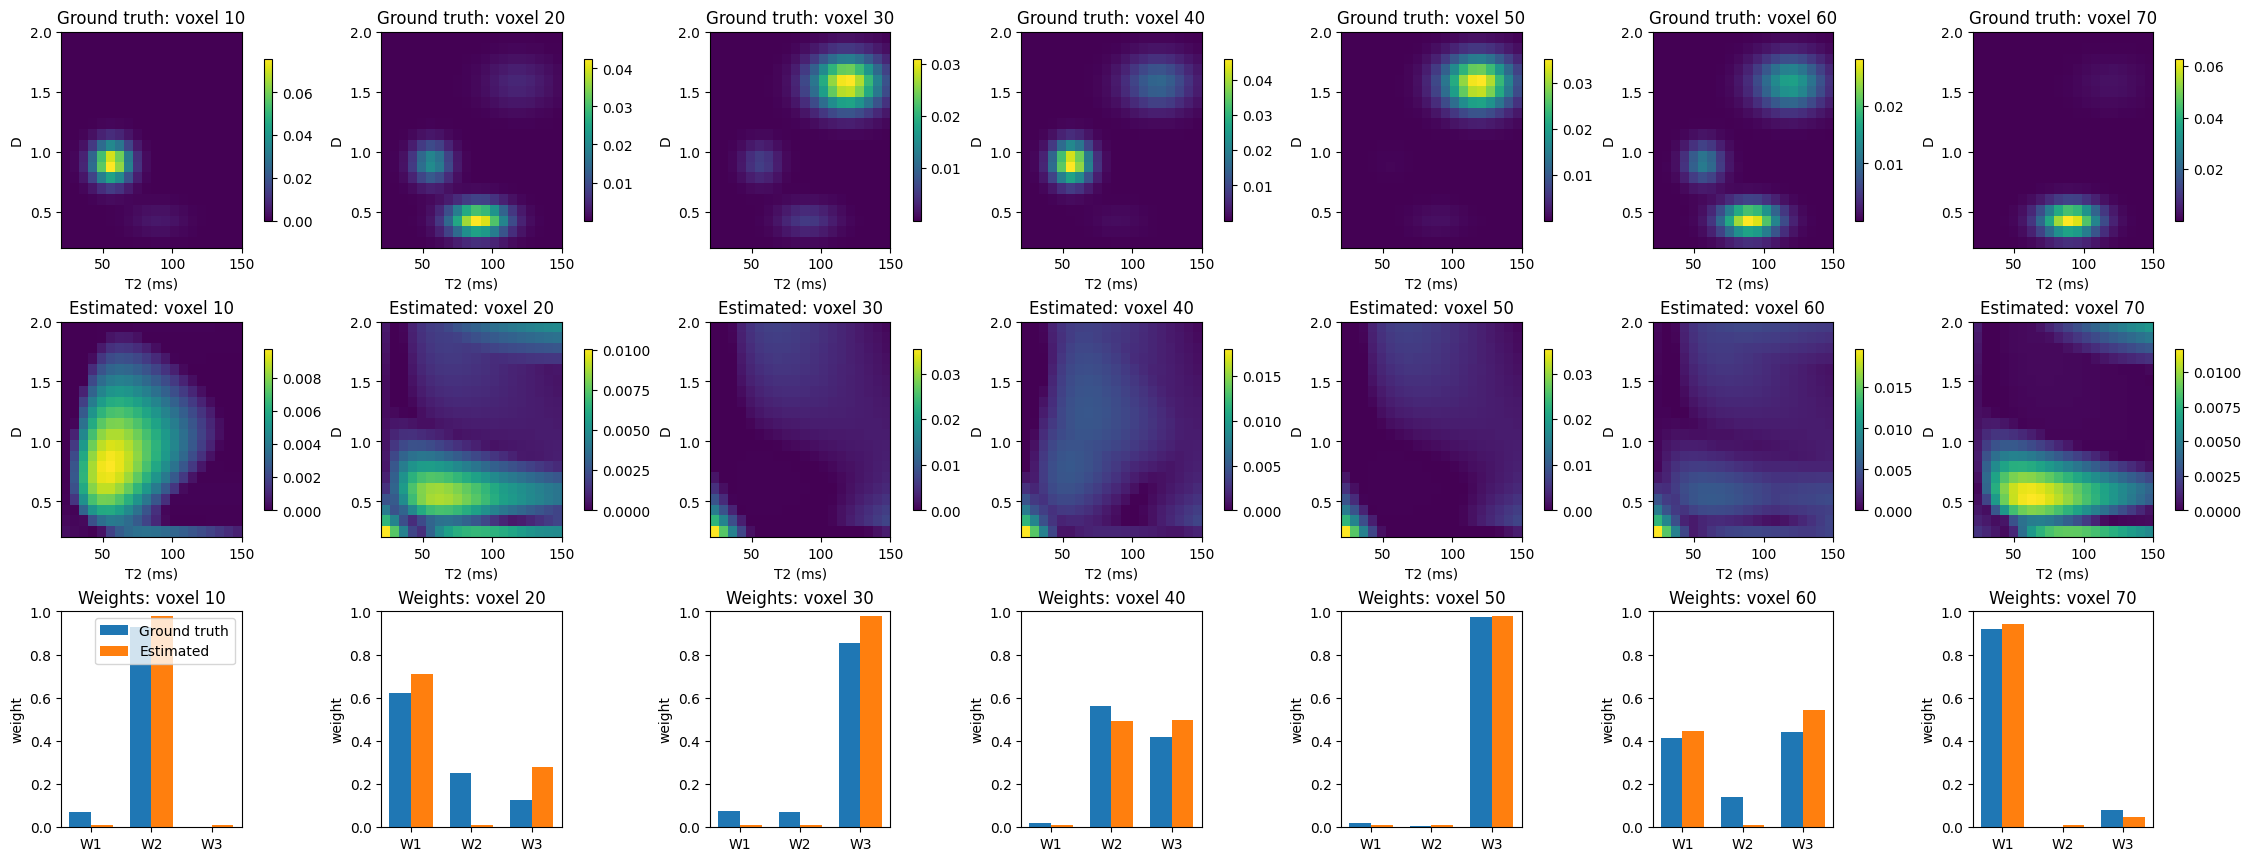

iter 0: loss=4394.1139, fit_err=278931.075831, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 2, entropy prior: estimated C, W MAE 0.142


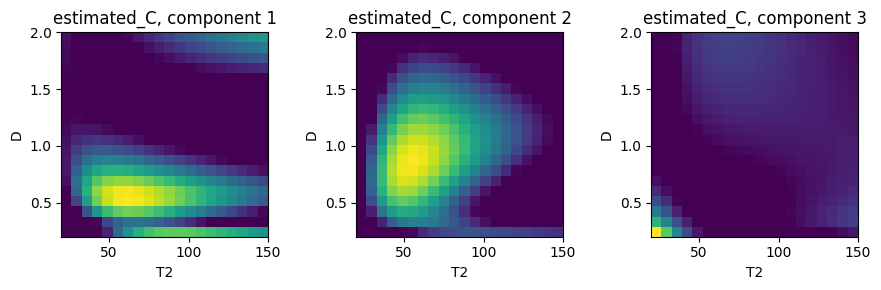

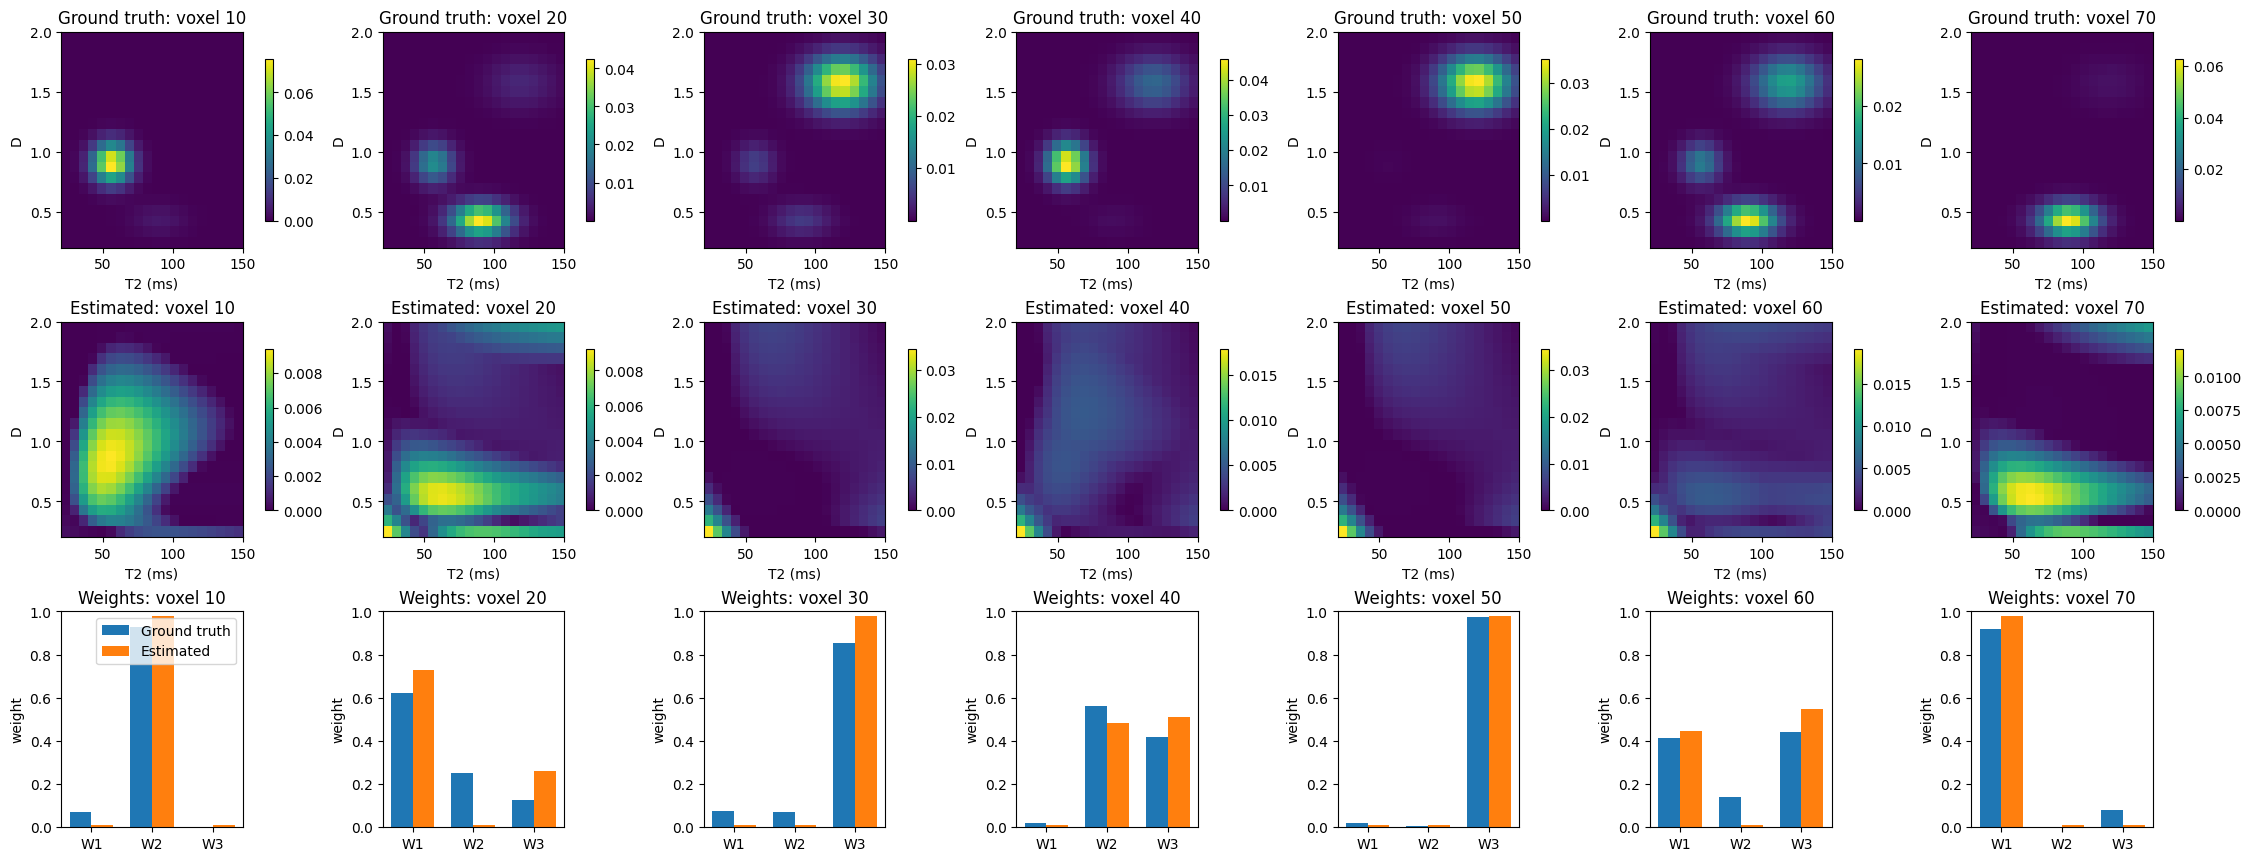

Seed 3: true C (first row) vs initial C (second row), starting W MAE 0.154


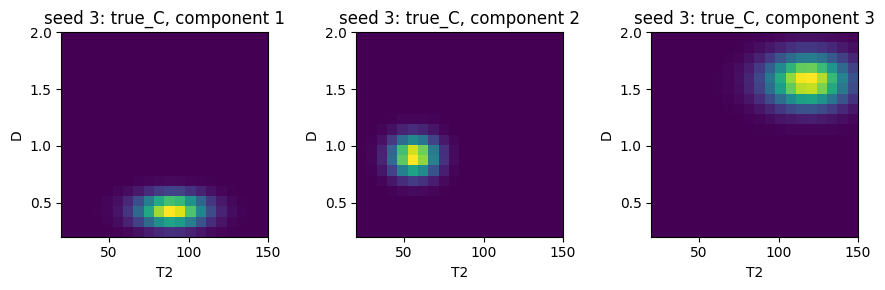

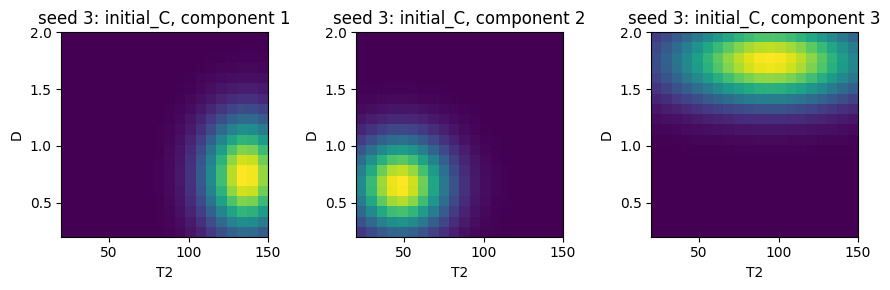



iter 0: loss=2380.8193, fit_err=175392.919596, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 3, dirichlet prior: estimated C, W MAE 0.079


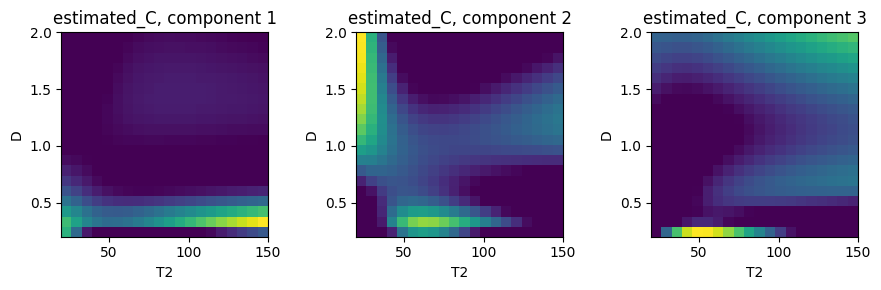

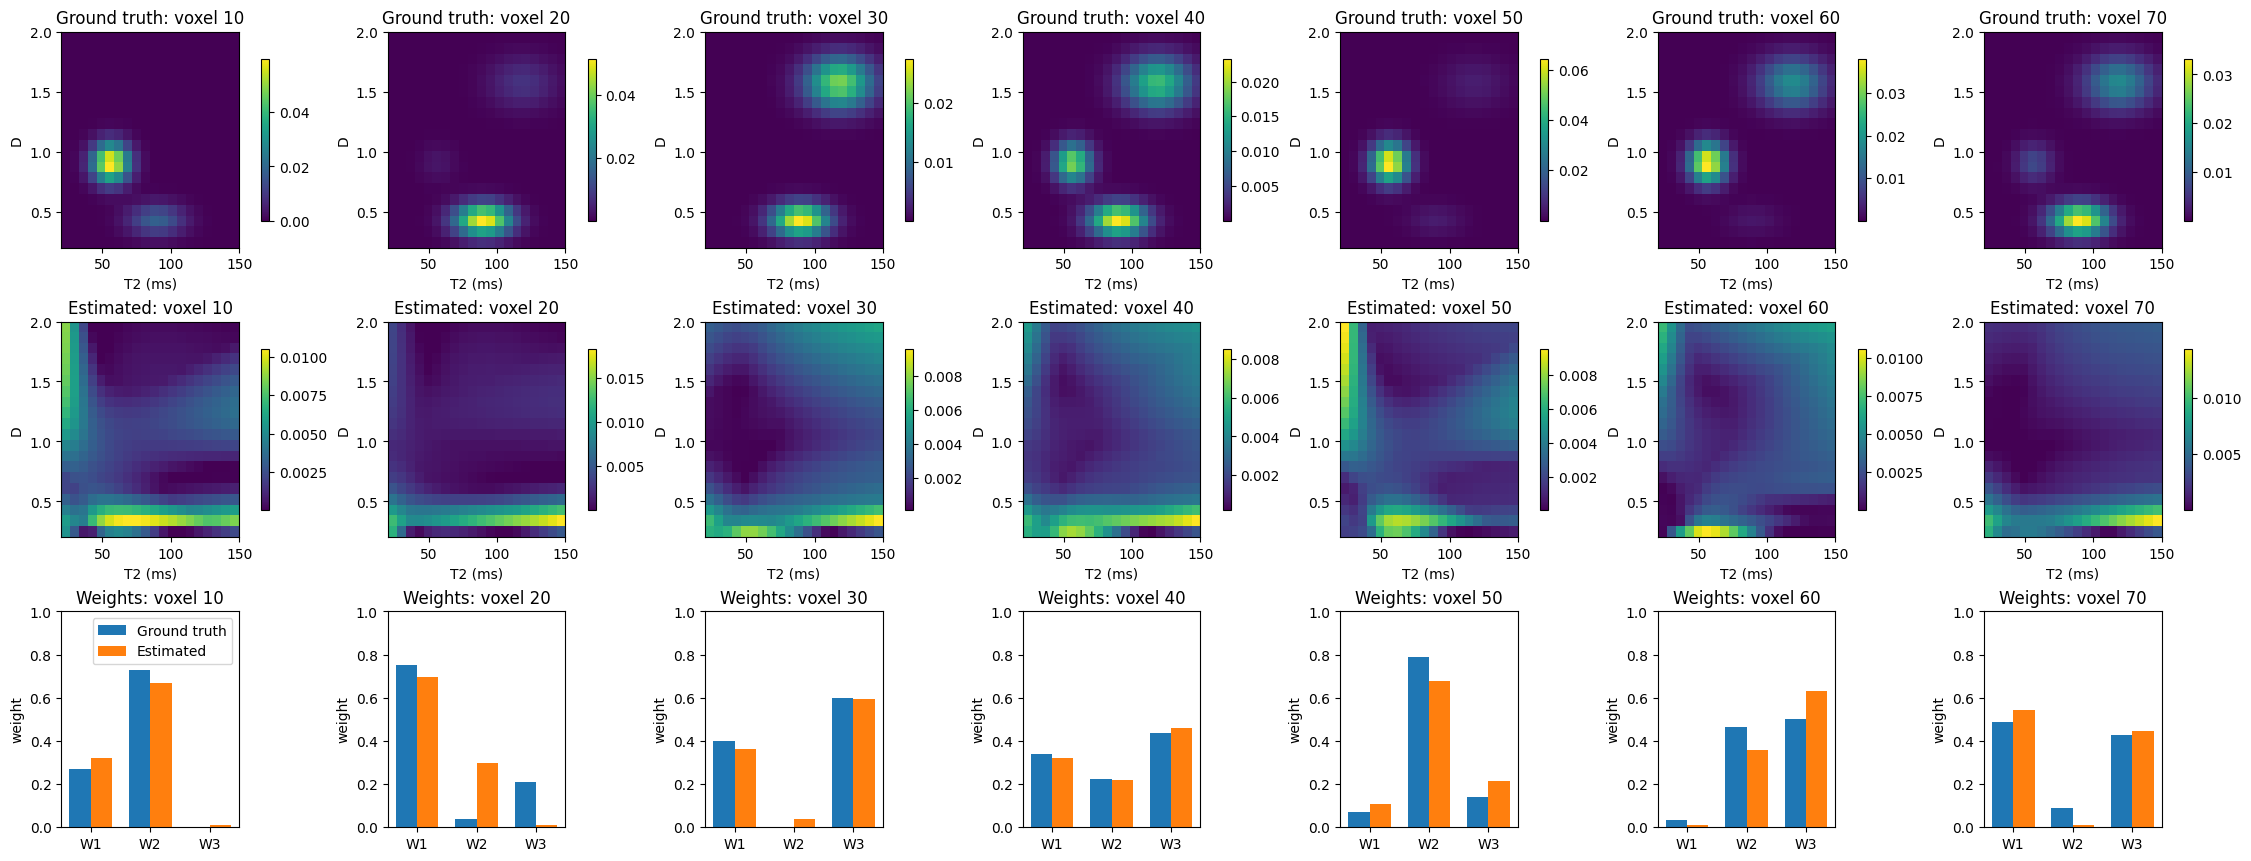

iter 0: loss=3019.8128, fit_err=179873.676238, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 3, entropy prior: estimated C, W MAE 0.079


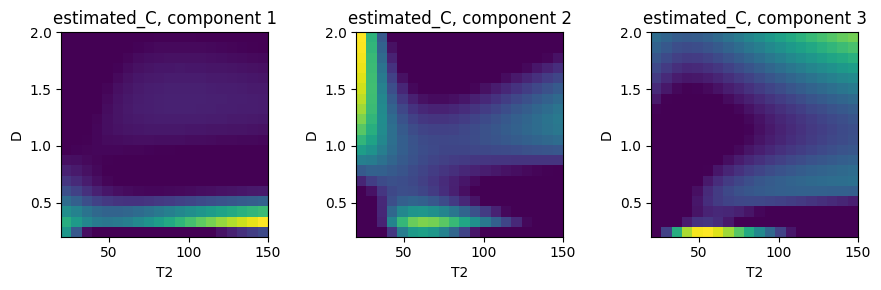

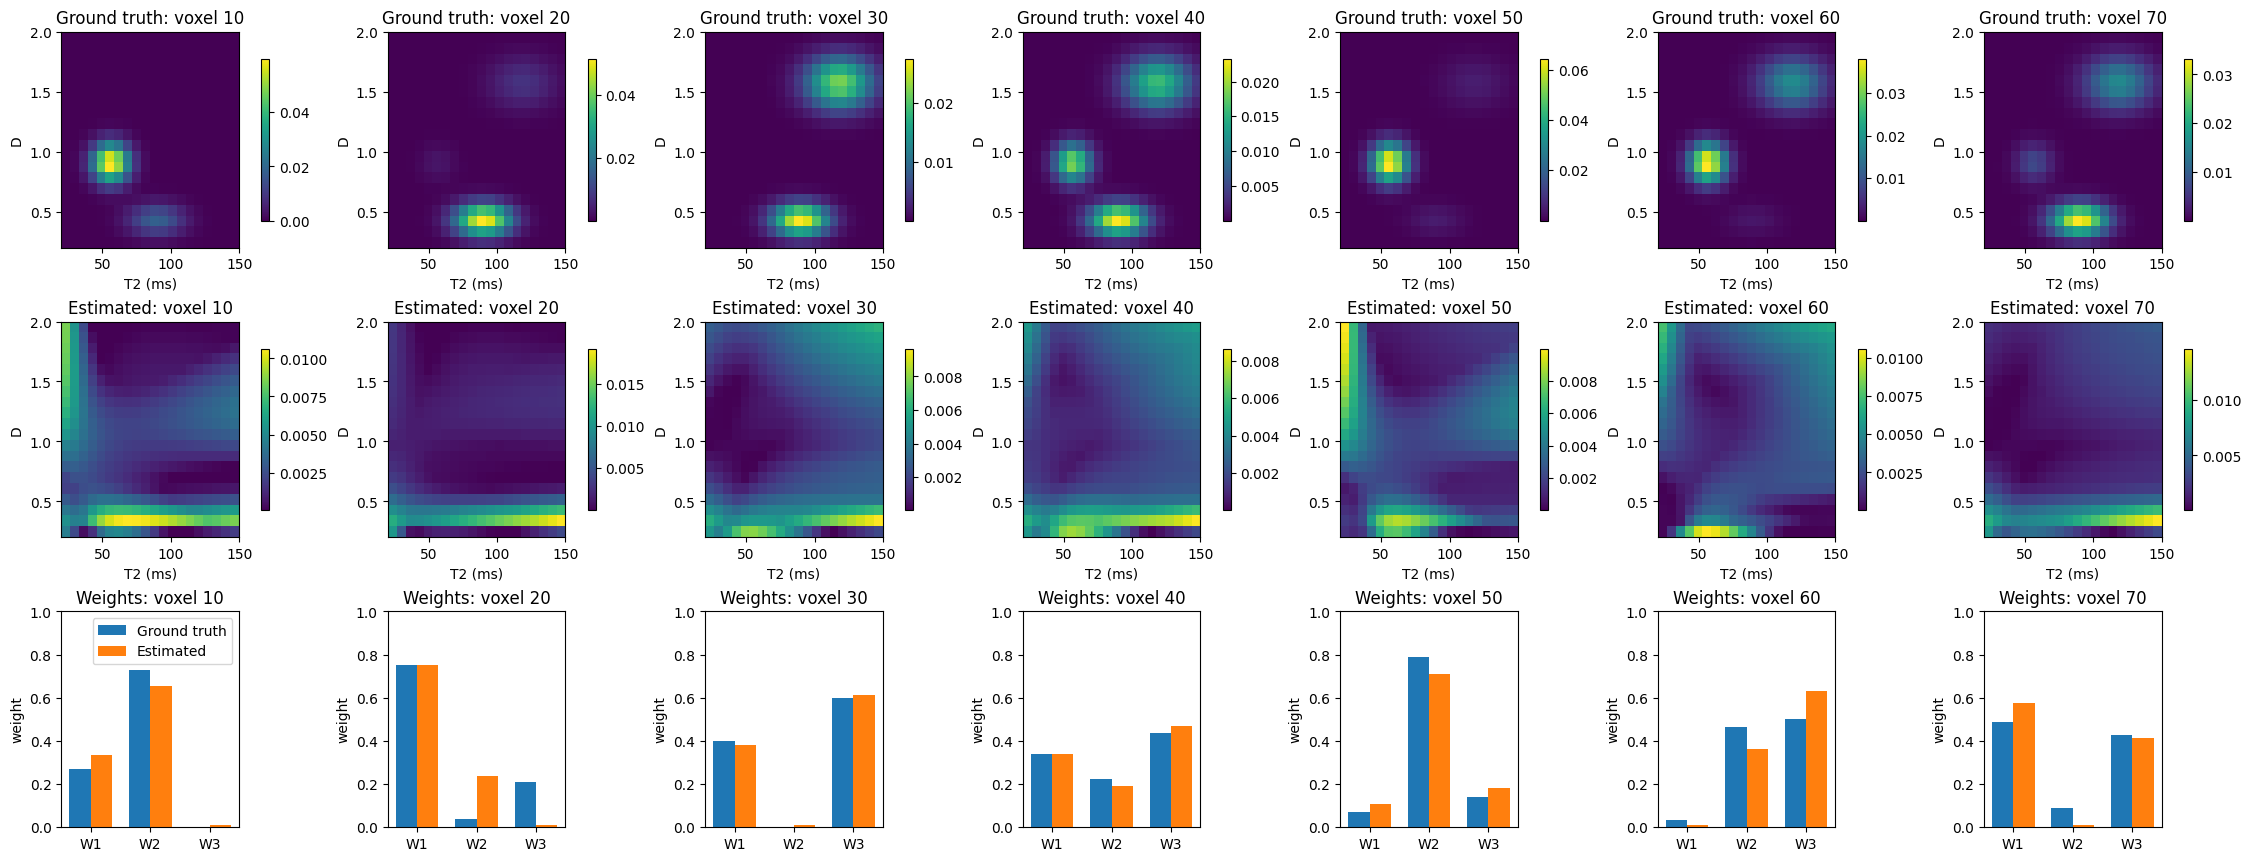

Seed 4: true C (first row) vs initial C (second row), starting W MAE 0.173


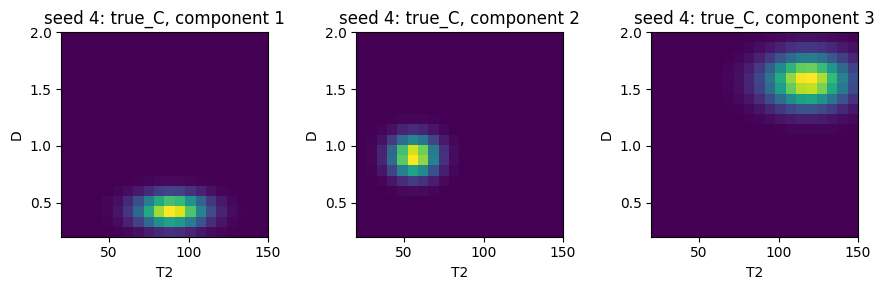

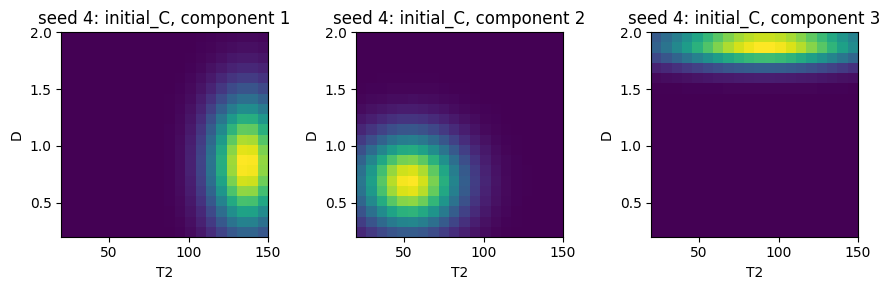



iter 0: loss=2590.4525, fit_err=190472.713139, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 4, dirichlet prior: estimated C, W MAE 0.187


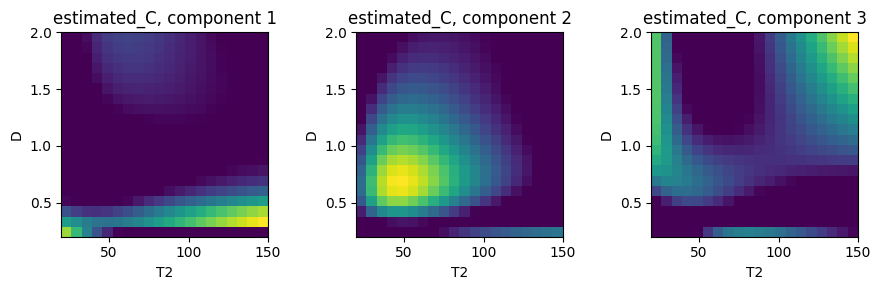

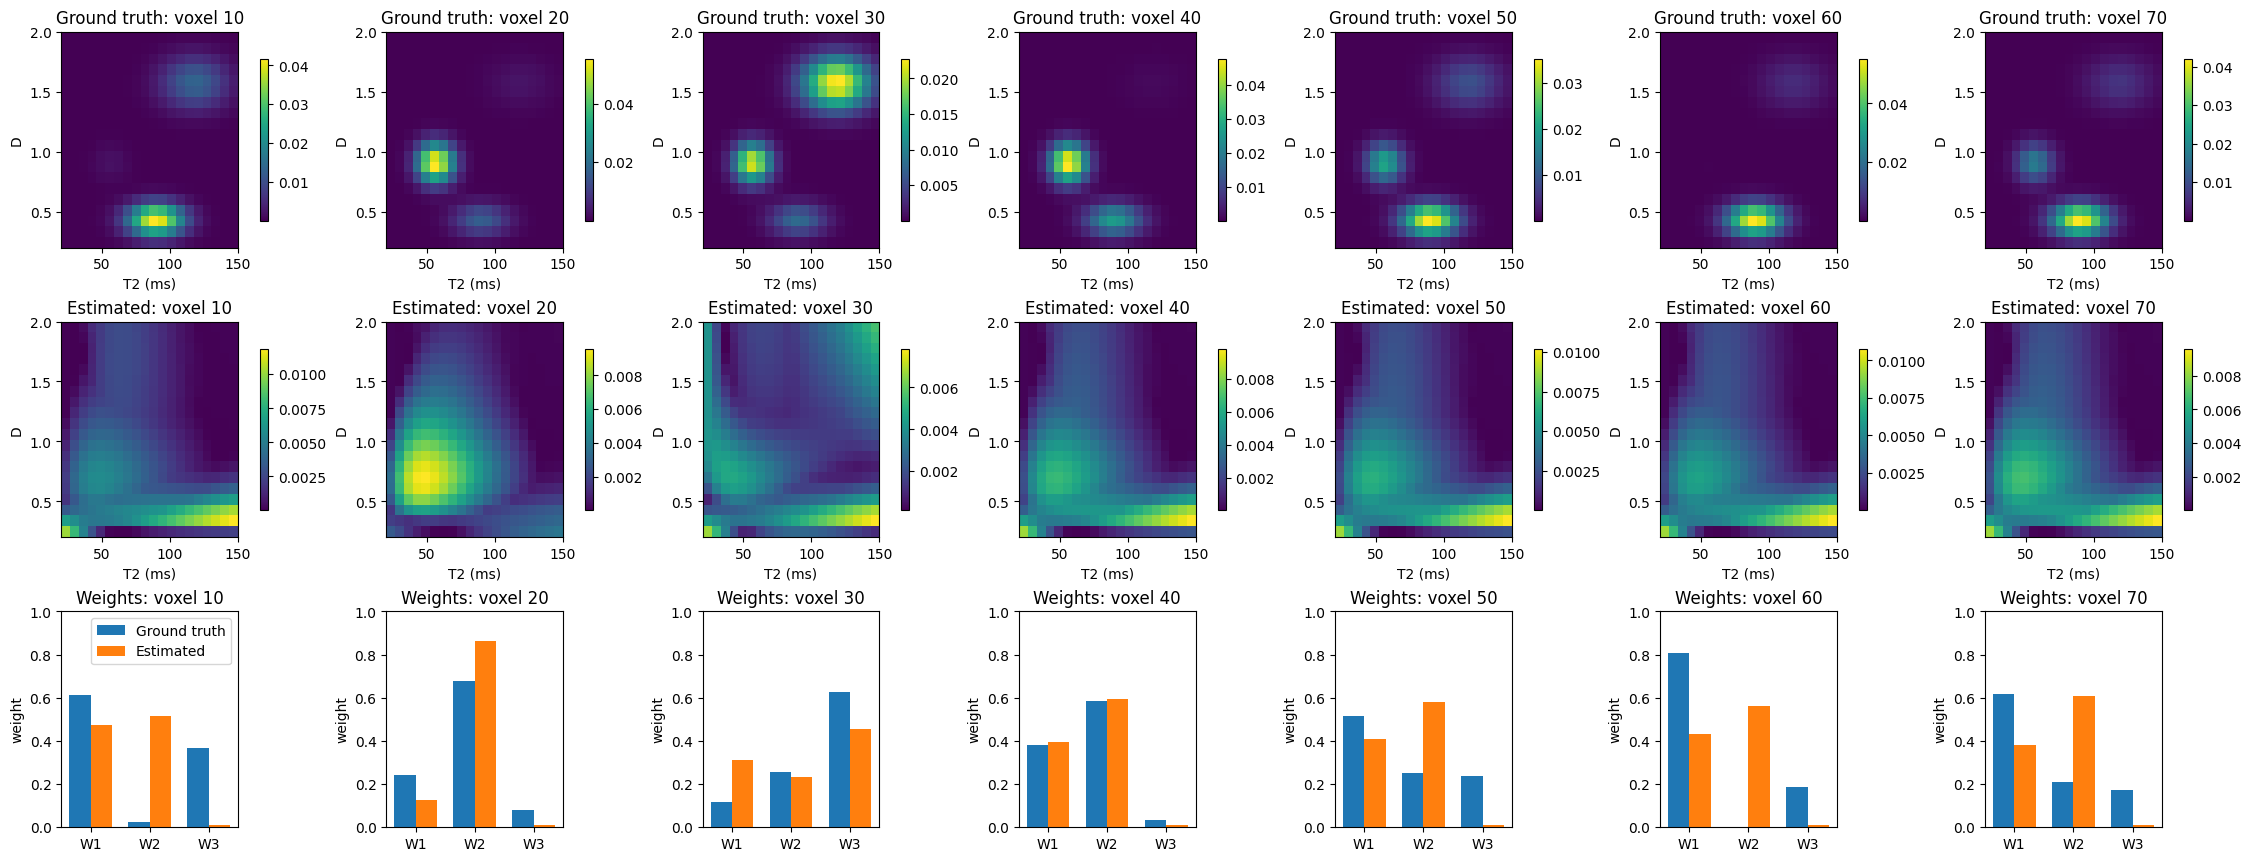

iter 0: loss=3236.6086, fit_err=195004.954027, sigma2=36.000000, lam=0.0000, alpha=1.0000
Seed 4, entropy prior: estimated C, W MAE 0.105


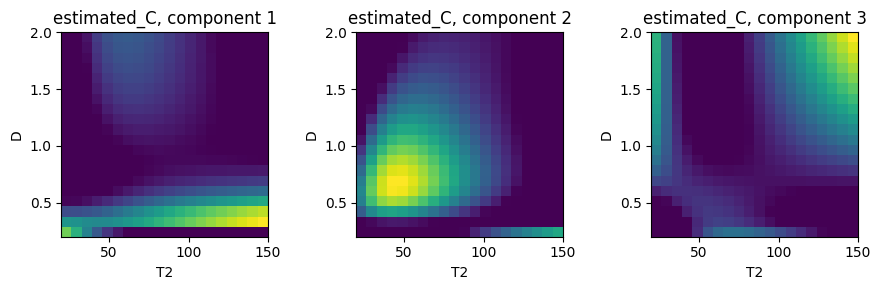

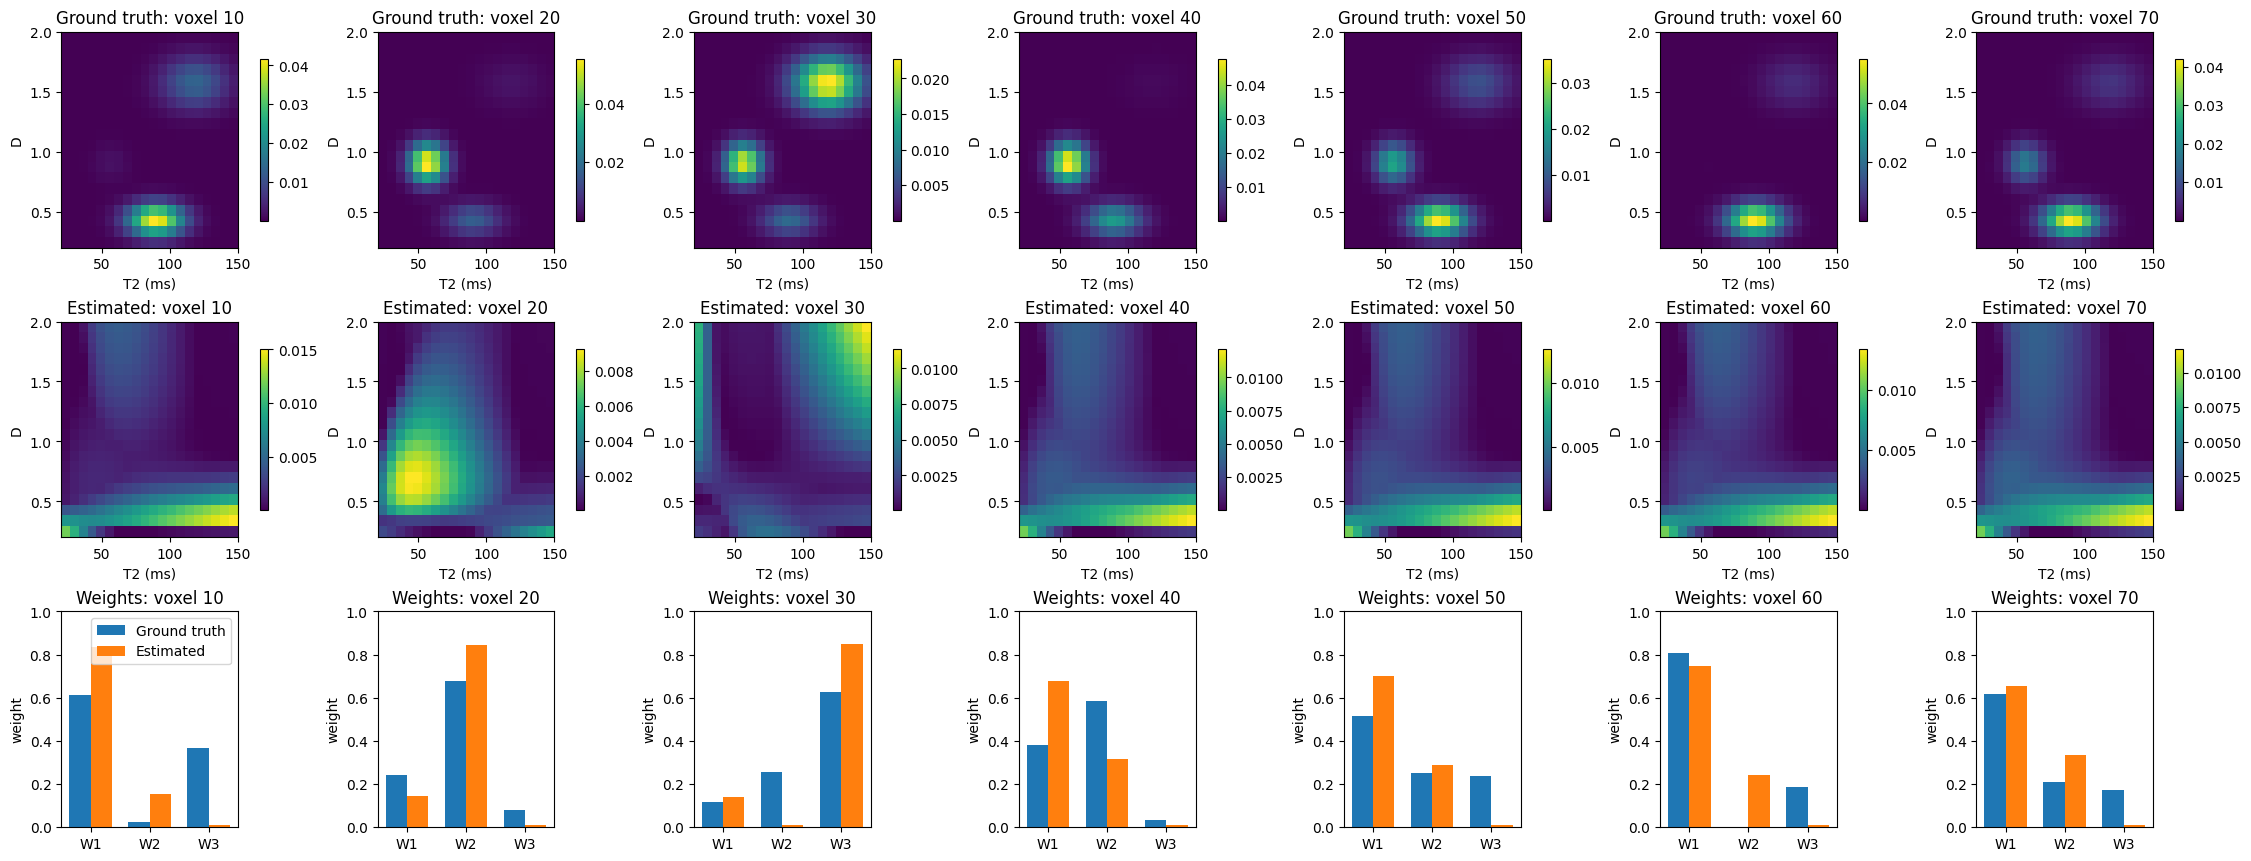

W MAE per seed: start, dirichlet, entropy
[[0.264 0.24  0.48 ]
 [0.301 0.155 0.108]
 [0.261 0.127 0.142]
 [0.154 0.079 0.079]
 [0.173 0.187 0.105]]
mean: [0.23  0.157 0.183]


In [50]:
# Dirichlet vs entropy prior on the same data, over several seeds
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

rows = []
for seed in range(5):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    #^^^ This function could be re-written to not have so many arguments 
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")


    # ----------------


    R = 10
    U, s, Vmat = apply_SVD_to_A(A, R)

    # C0 stays on the physical D–T2 grid, so it does not depend on R.
    Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

    # Refit weights because U @ Csmall0 has changed.
    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        W_est_dirichlet, _, Csmall_est_dirichlet, *_ = run_optimisation(
            Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, K=K, R=R, eps=1e-10, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-8, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
            verbose_every=300, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, estimate_C(Vmat, s, Csmall_est_dirichlet), W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])
        
        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))


#### Same comparison: signal-averaged initialisation
Average the signals, then one NNLS. Same seeds and settings as above, only the initialisation changes.

Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.294


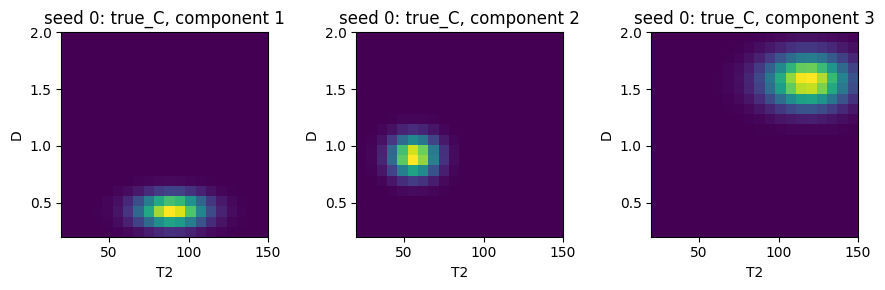

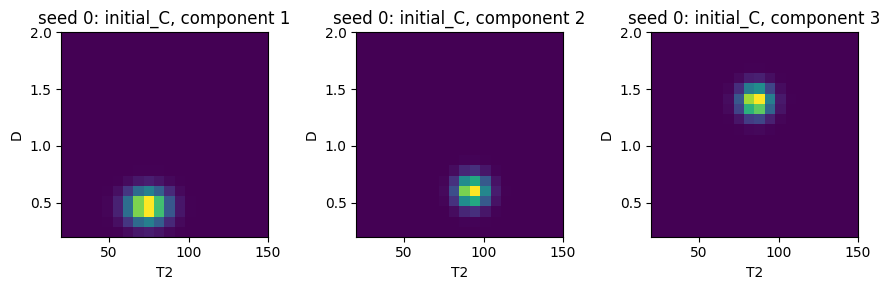



iter 0: loss=3220.0042, fit_err=235643.705161, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 100: loss=2499.4729, fit_err=186009.819106, sigma2=36.000000, lam=0.0100, alpha=0.5355
iter 200: loss=2494.7731, fit_err=185811.294031, sigma2=36.000000, lam=0.0100, alpha=0.5263
Seed 0, dirichlet prior: estimated C, W MAE 0.239


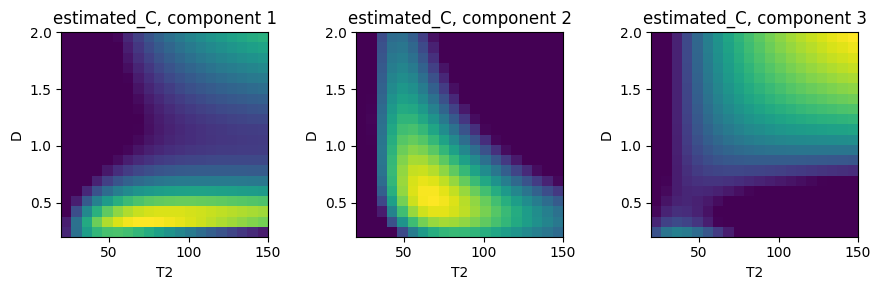

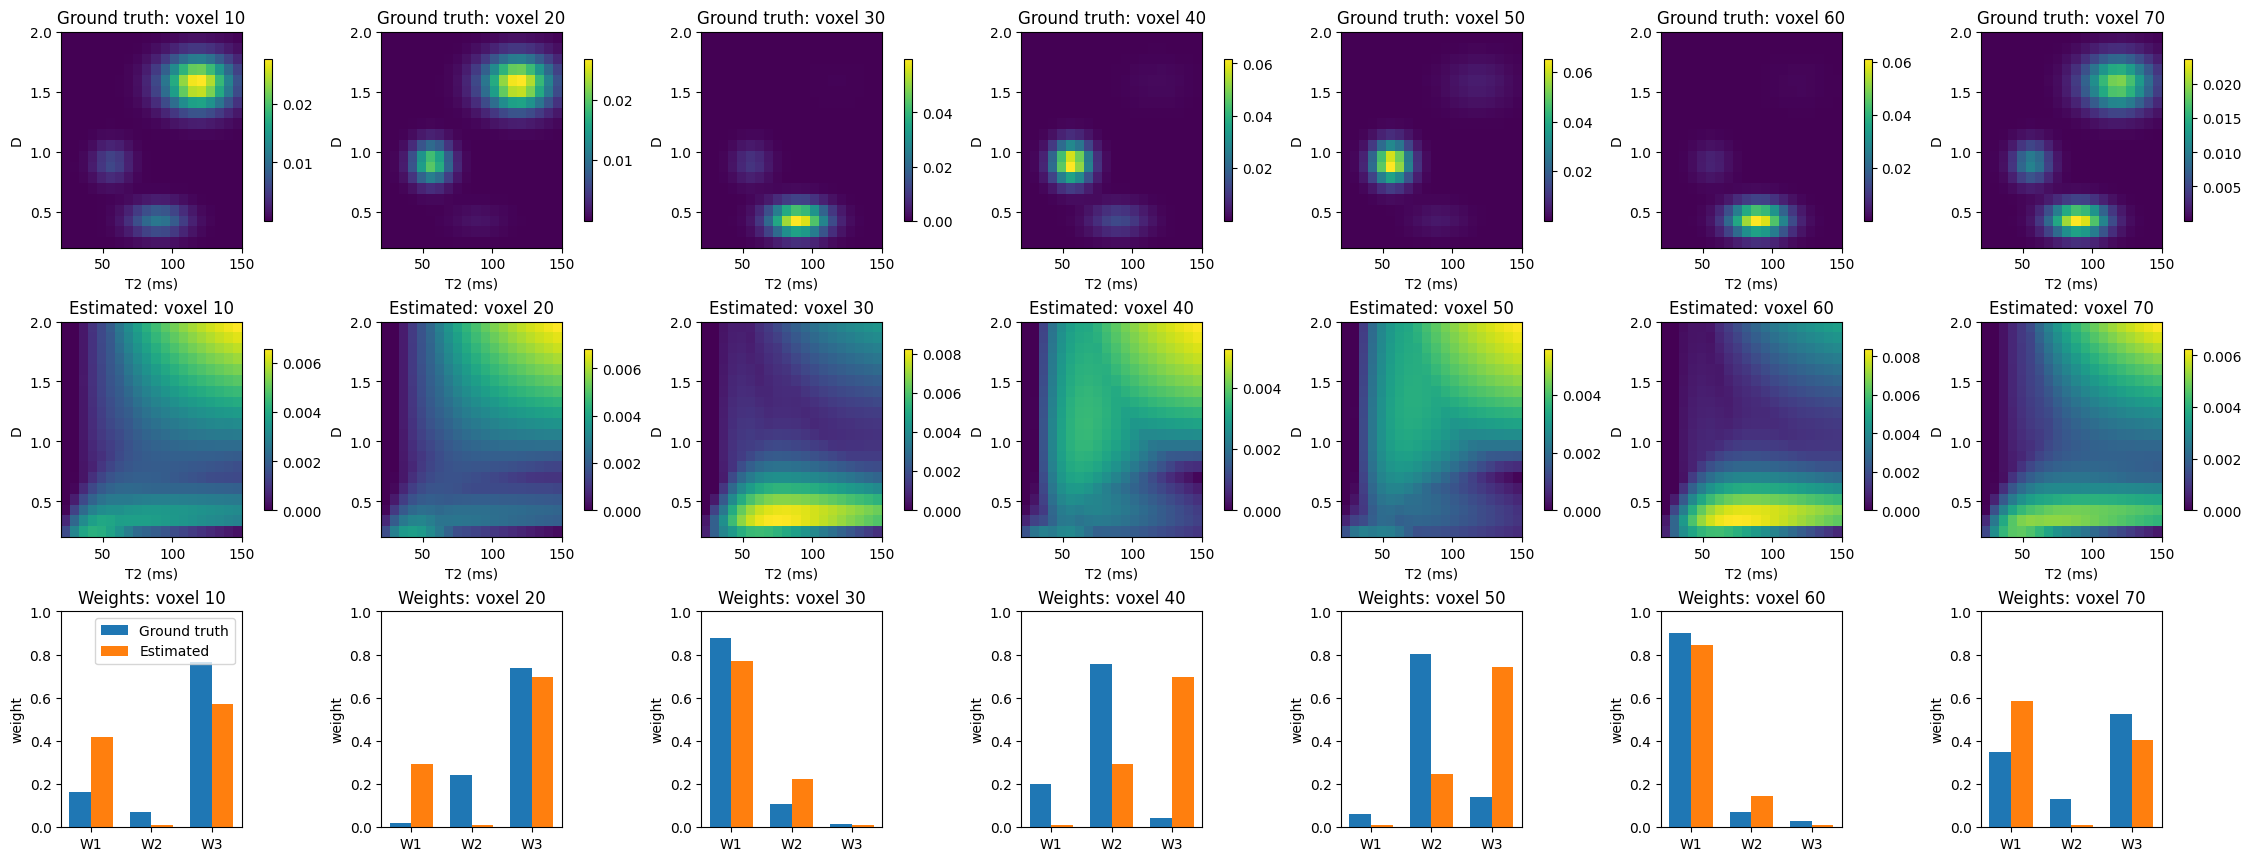

iter 0: loss=3974.4885, fit_err=258494.787324, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 100: loss=3484.7850, fit_err=216904.308173, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 200: loss=3464.9379, fit_err=217686.364550, sigma2=36.000000, lam=0.0100, alpha=1.0000
Seed 0, entropy prior: estimated C, W MAE 0.261


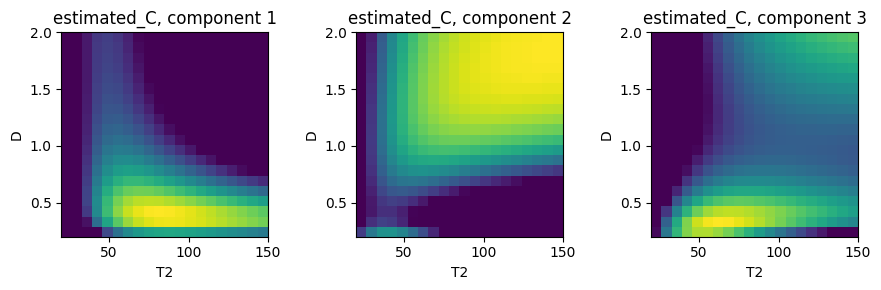

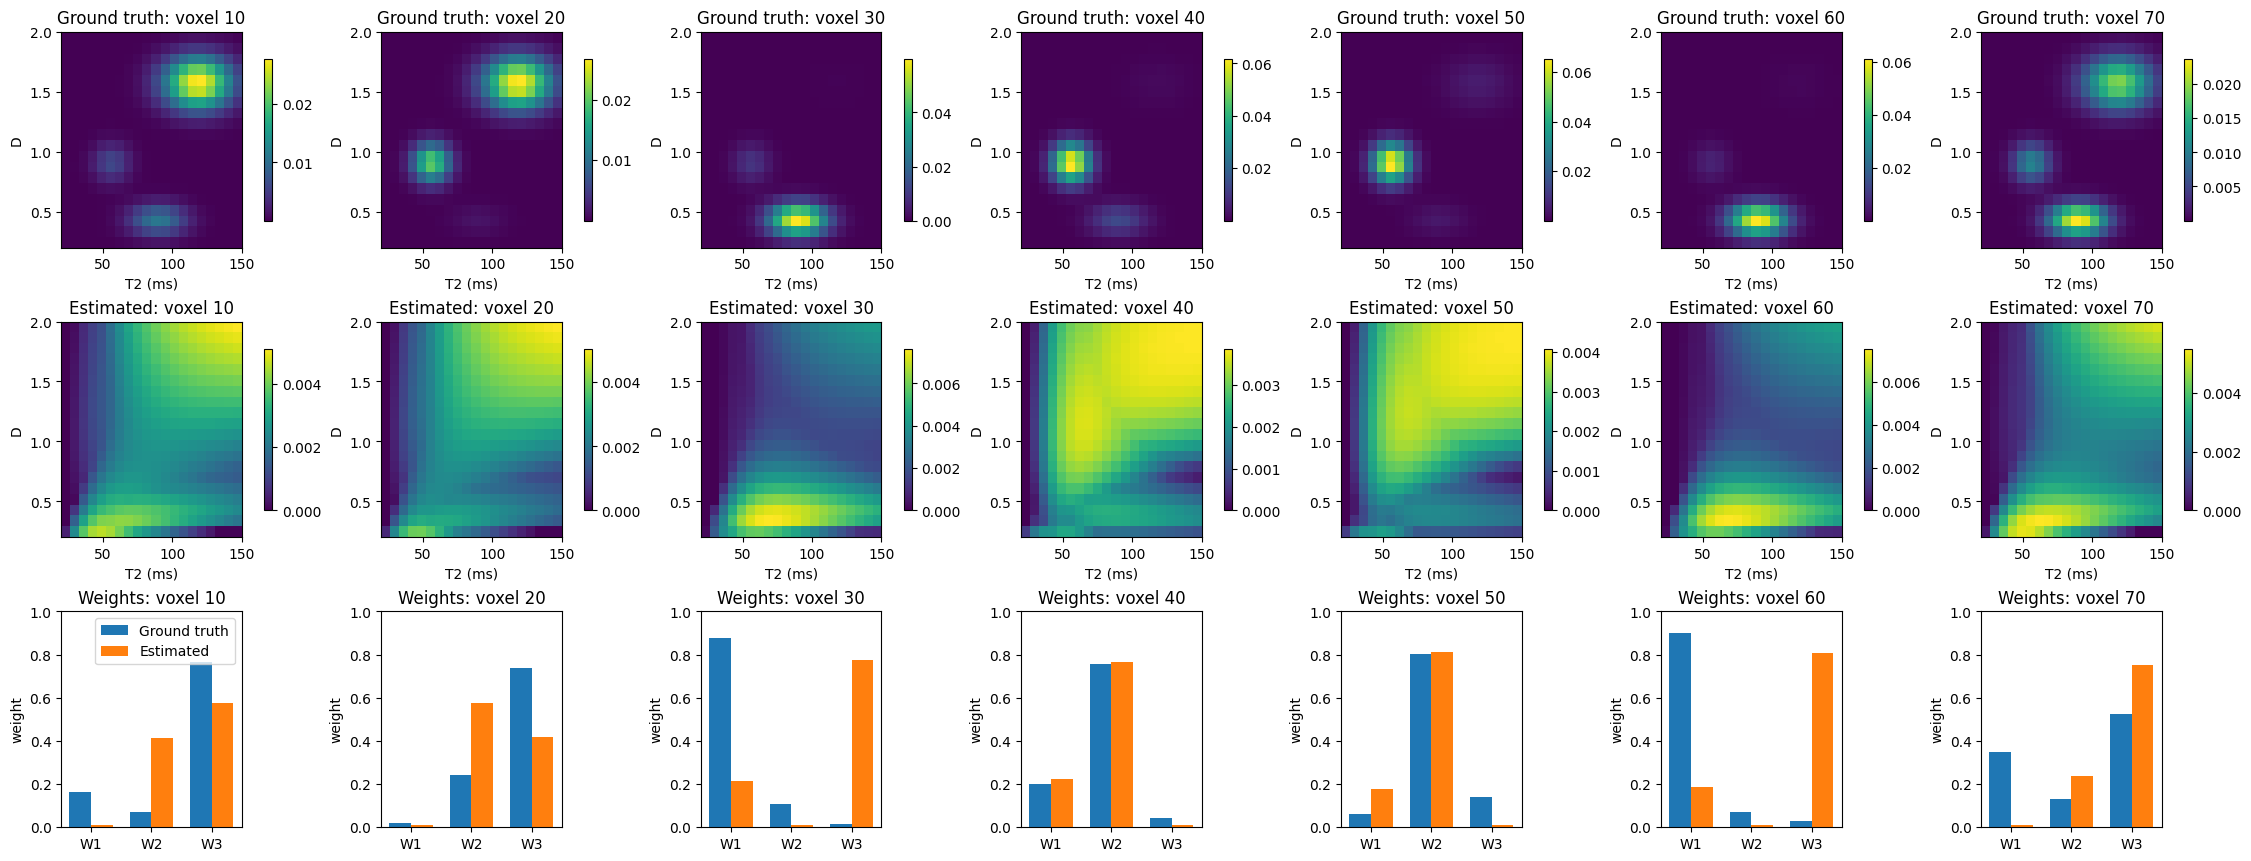

W MAE per seed: start, dirichlet, entropy
[[0.294 0.239 0.261]]
mean: [0.294 0.239 0.261]


In [54]:
# Dirichlet vs entropy prior on the same data, over several seeds
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

rows = []
for seed in range(1):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    #^^^ This function could be re-written to not have so many arguments 
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")


    # ----------------


    R = 7
    U, s, Vmat = apply_SVD_to_A(A, R)

    # C0 stays on the physical D–T2 grid, so it does not depend on R.
    Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

    # Refit weights because U @ Csmall0 has changed.
    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        W_est_dirichlet, _, Csmall_est_dirichlet, *_ = run_optimisation(
            Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, K=K, R=R, eps=1e-10, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-2, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
            verbose_every=100, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, estimate_C(Vmat, s, Csmall_est_dirichlet), W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])

        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))


**Result:**
- Both priors improve the weights from the initialisation on every seed. Neither prior is clearly better.
- On average the no mean initialisation ends slightly better, but which one wins changes from seed to seed.
- Seeds that end badly also fit the data worse than the noise level, which points to a bad starting point rather than a bad prior
